# LOAD LIBRARIES

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from scipy.stats import linregress
from statsmodels.nonparametric.smoothers_lowess import lowess

# CONFIGURATION

In [34]:
START_DATE, END_DATE = '2022-09-01', '2023-10-05'
TIME_RESOLUTION = '4'
TARGET_FLUX = 'n2o'
QUALITY_FLAG = 'qcf0'
N_FOLDS = 5
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
LOG_TRANSFORM = False
UNDERSAMPLE = False

# LOAD DATA

In [35]:
data_main = pd.read_csv(f'../data/processed/DRIVERS_dataset_{TIME_RESOLUTION}h.csv', low_memory=False)
data_main['timestamp_middle'] = pd.to_datetime(data_main['timestamp_middle'])
data_main.set_index('timestamp_middle', inplace=True)
data_main = data_main.loc[START_DATE:END_DATE]

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
data_main['id'] = range(0, len(data_main))

# CLEAN DATA

In [36]:
# Define the target variable based on the specified flux and quality flag
TARGET = f'flux_{TARGET_FLUX}_{QUALITY_FLAG}'

# keep complete copy for later use in SHAP analysis
data_complete = data_main.copy()

# Remove NAs in the target variable, as they cannot be used for training or evaluation
data_main = data_main[data_main[TARGET].notna()]

data_main

,flux_nee_qcf_f_mds,flux_n2o_qcf,flux_n2o_qcf0,flux_n2o_qcf_f_rf,flux_ch4_qcf_f_rf,flux_le_qcf_f_mds,flux_h_qcf_f_mds,flux_reco,flux_gpp,sw_in_pot,...,wfps_0.15_diff12h,wfps_0.15_diff24h,wfps_0.15_diff48h,wfps_0.3_diff12h,wfps_0.3_diff24h,wfps_0.3_diff48h,wfps_0.5_diff12h,wfps_0.5_diff24h,wfps_0.5_diff48h,id
timestamp_middle,,,,,,,,,,,,,,,,,,,,,
2022-09-01 04:00:00,2.401638,0.197836,0.242429,0.197601,2.043430,6.856706,-4.799923,5.479219,3.077580,166.711538,...,-0.303753,-0.094928,-0.469126,-0.077292,0.166907,-0.231051,-0.066340,-0.506643,-0.905881,1
2022-09-01 08:00:00,-12.171185,-0.189762,-0.020742,-0.170371,-2.530666,88.157572,62.396847,6.235522,18.406707,866.083500,...,-0.499575,-0.485645,-0.278392,-0.165390,0.181054,-0.259238,-0.052891,-0.653769,-0.534071,2
2022-09-01 12:00:00,-10.763956,-0.184124,-0.233794,-0.184124,-0.585171,193.021731,95.585314,7.240746,18.004702,922.577125,...,-0.561318,-0.651114,-0.275279,-0.225380,-0.100895,-0.249998,-0.149358,-0.356730,-0.395967,3
2022-09-02 08:00:00,-14.678085,-0.258137,-0.265809,-0.266423,-5.932829,189.757780,138.704429,6.985861,21.663946,860.976250,...,-0.657767,-0.833842,-1.319487,-0.195572,-0.264905,-0.083852,-0.043227,-0.291053,-0.944822,8
2022-09-02 12:00:00,-4.717125,-0.409255,-0.433862,-0.349672,-4.119085,117.929456,27.416452,7.758615,12.475740,917.549250,...,-0.527953,-0.690822,-1.341935,-0.247245,-0.263260,-0.364155,-0.177544,-0.325586,-0.682316,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-03 20:00:00,3.640106,0.881749,0.904912,0.881749,2.386634,4.501773,-29.475935,5.031657,1.391552,0.000000,...,-0.163795,-0.529972,-0.915471,-0.127161,-0.317963,-0.554744,-0.120864,-0.144342,-0.216338,2387
2023-10-04 08:00:00,3.943206,0.781407,0.781407,0.781407,-6.808914,94.529160,153.159578,5.475166,1.531960,666.801250,...,-0.465864,-0.629659,-0.944960,-0.163389,-0.290550,-0.505746,-0.014372,-0.135236,-0.212566,2390
2023-10-04 12:00:00,4.388155,1.360674,1.360674,1.360674,-0.815610,60.784127,75.674845,5.667781,1.279627,724.836375,...,-0.356637,-0.569158,-1.025921,-0.269625,-0.314303,-0.559491,-0.000076,-0.140468,-0.220404,2391


# SELECT FEATURES

In [37]:
# Import the best features
# path = '../data/processed/best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '_' + TIME_RESOLUTION + 'h.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 5
# path = '../data/processed/ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '_' + TIME_RESOLUTION + 'h.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]


# Selection based on 'ranked_features' and picking the most important features from each of the driver categories
selected_features = [
'n_decay_timed',
'timesince_fert', 
'timesince_soil_preparation',
'wfps_0.3_lag48h',
'wfps_0.3_diff24h',
'ts_0.3_roll48hmean',
'flux_gpp_roll48hsum'
]

# Keep only the best feature set
data = data_main[selected_features + [TARGET]].copy()

# Split dataset for the final evaluation
data_train = data.iloc[:int(0.8 * len(data))].copy()
data_test = data.iloc[int(0.8 * len(data)):].copy()

data

,n_decay_timed,timesince_fert,timesince_soil_preparation,wfps_0.3_lag48h,wfps_0.3_diff24h,ts_0.3_roll48hmean,flux_gpp_roll48hsum,flux_n2o_qcf0
timestamp_middle,,,,,,,,
2022-09-01 04:00:00,0.0,30,30,31.249383,0.166907,19.504965,72.318492,0.242429
2022-09-01 08:00:00,0.0,30,30,31.228738,0.181054,19.468605,71.271602,-0.020742
2022-09-01 12:00:00,0.0,30,30,31.114142,-0.100895,19.420058,77.264540,-0.233794
2022-09-02 08:00:00,0.0,30,30,30.788446,-0.264905,18.991678,94.061389,-0.265809
2022-09-02 12:00:00,0.0,30,30,30.965039,-0.263260,18.888952,90.494931,-0.433862
...,...,...,...,...,...,...,...,...
2023-10-03 20:00:00,0.0,30,7,53.778983,-0.317963,15.991667,12.512343,0.904912
2023-10-04 08:00:00,0.0,30,7,53.566596,-0.290550,16.009387,9.217772,0.781407
2023-10-04 12:00:00,0.0,30,7,53.487387,-0.314303,16.016933,7.554424,1.360674


# SELECT MODEL

In [38]:
# Load hyperparameters from JSON file
path = '../data/processed/best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '_' + TIME_RESOLUTION + 'h.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

model = XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.8887995089067299, 'gamma': 0.4692763545078751, 'learning_rate': 0.005077876584101433, 'max_depth': 14, 'min_child_weight': 5, 'n_estimators': 260, 'subsample': 0.7216968971838151}


# IMBALANCE HANDLING

## UNDER SAMPLING

In [39]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling target data below: {cutoff_value}')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=0.5, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('timestamp_middle')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.');

## LOG TRANSFORMATION

In [40]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

if LOG_TRANSFORM:
    data[TARGET] = log_transform(data[TARGET])
    print('The target was log transformed')
    # Show histogram of TARGET
    plt.hist(data[TARGET], bins=20)
    plt.xlabel(TARGET)
    plt.show()
    # Show timeseries
    data[TARGET].plot(x_compat=True, style='.');

# CROSS-VAL SPLITS

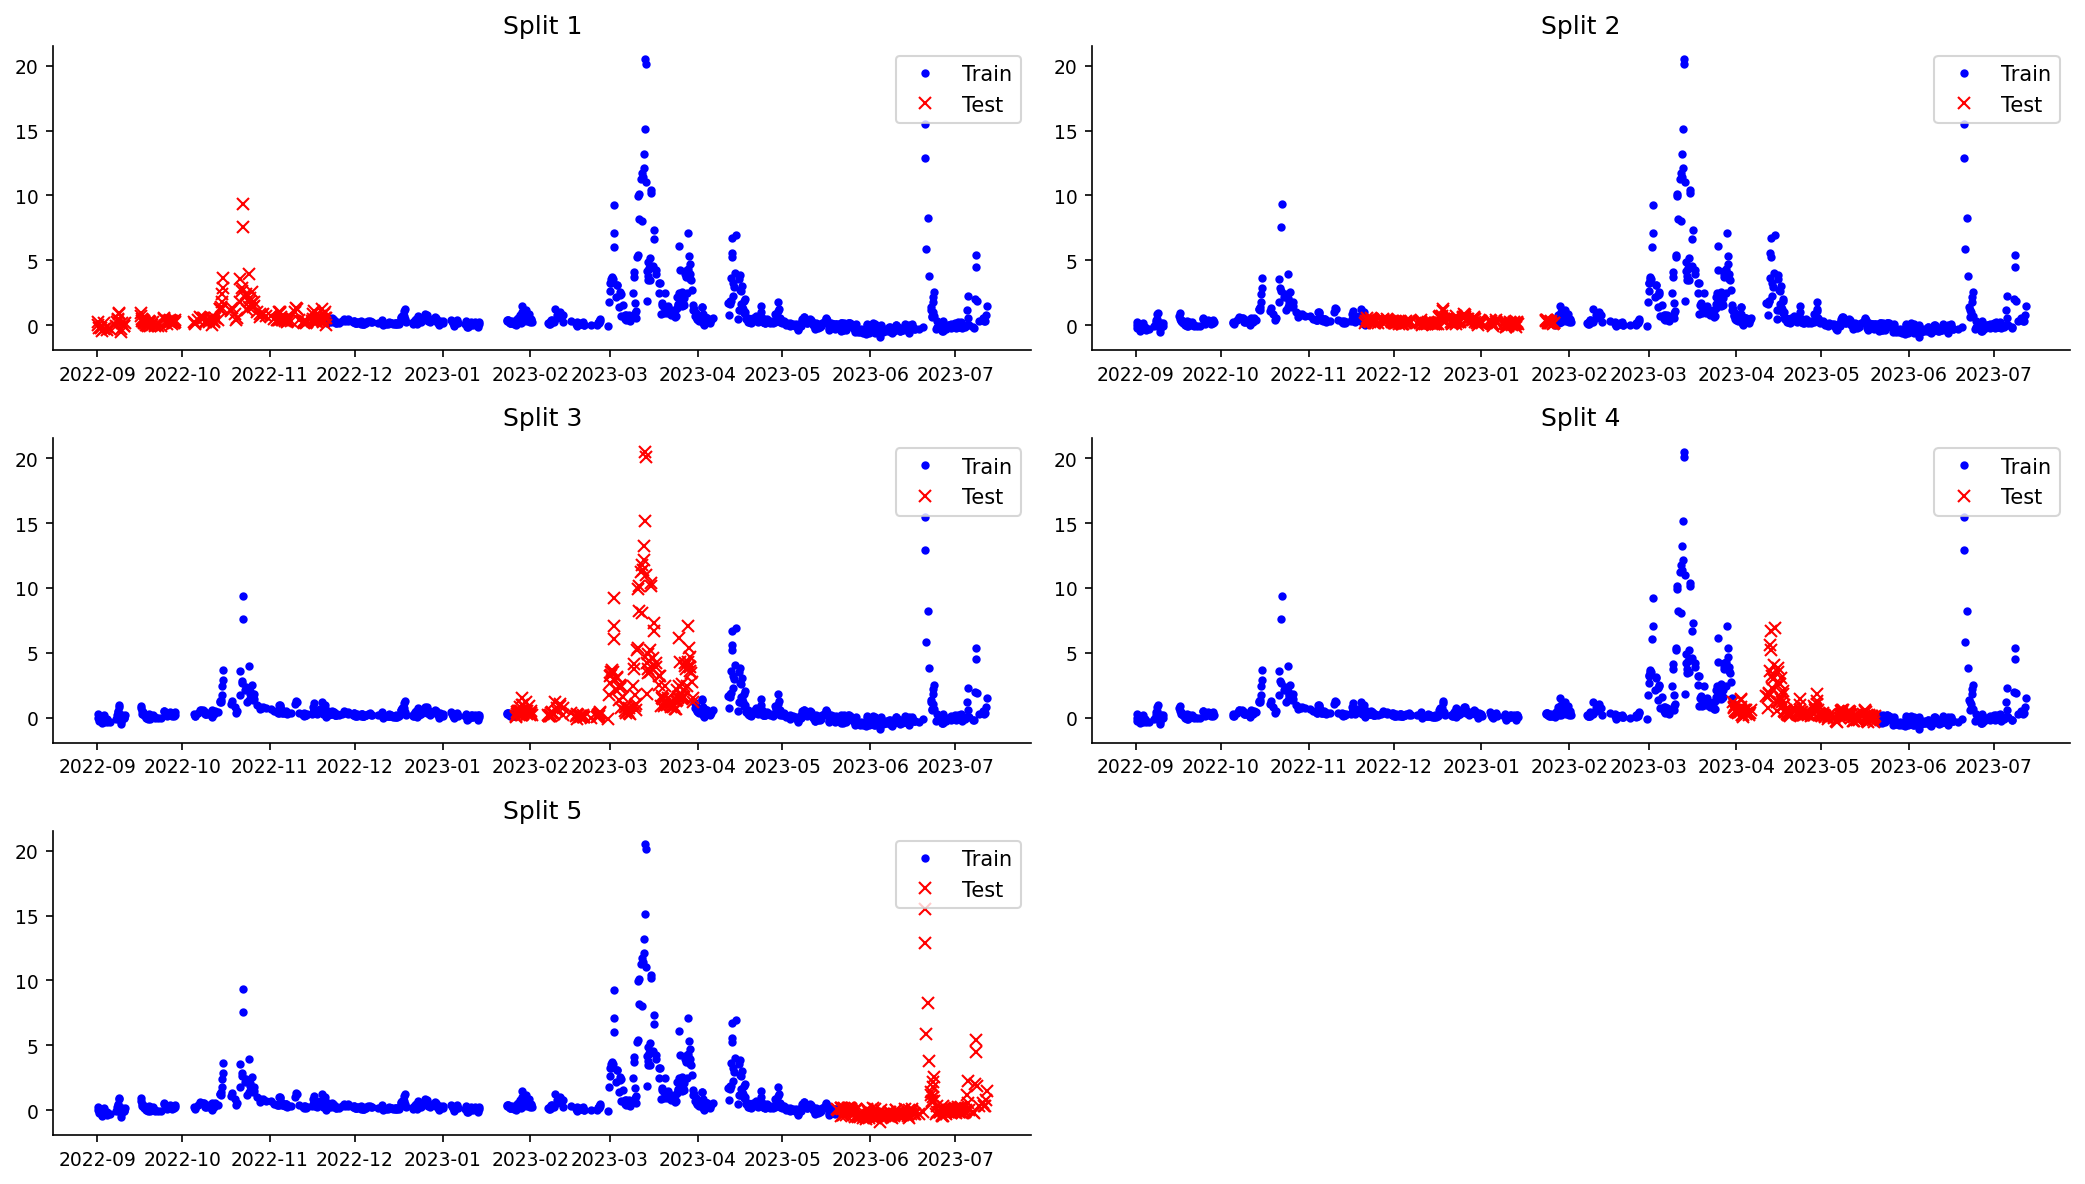

In [41]:
def create_splits(X, y, n_folds):
    """Creates train-test splits using KFold."""
    # Select method for splitting
    splitter = KFold(n_splits=n_folds, shuffle=False)
    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y)]
    return splits


X = data_train.drop(columns=TARGET)
y = data_train[TARGET]

# Create the splits
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)

# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1}")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# CROSS-VALIDATION

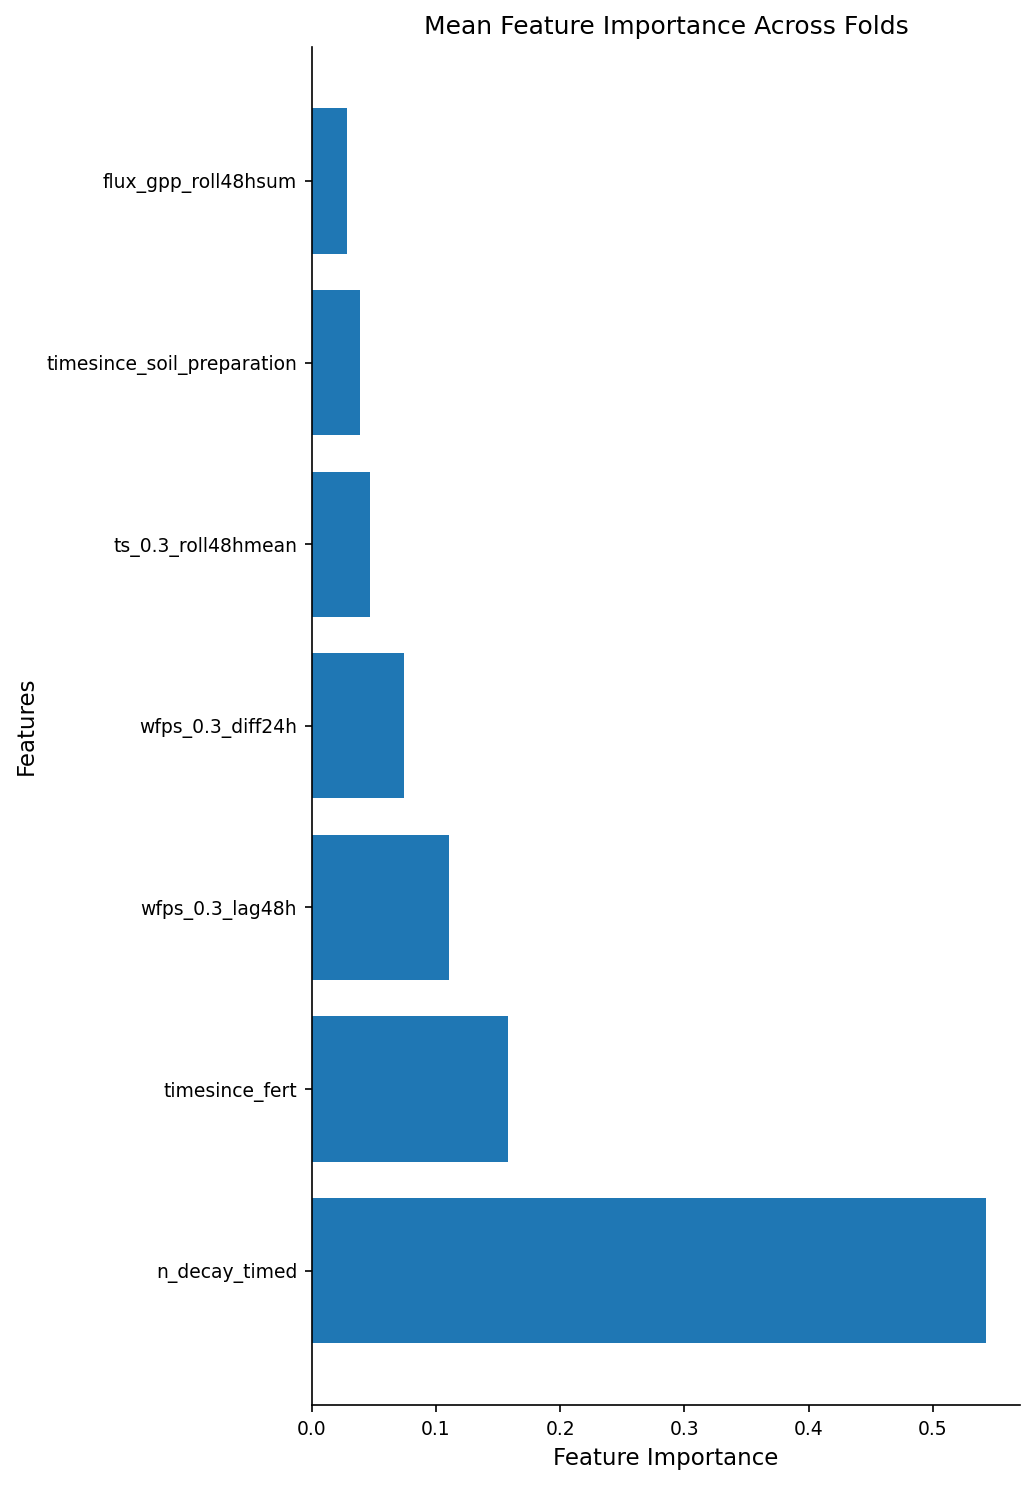

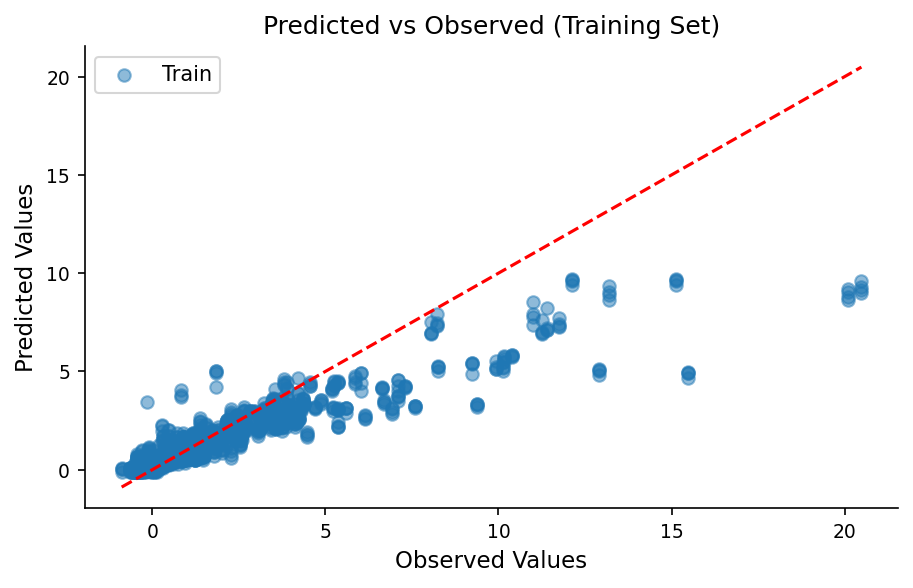

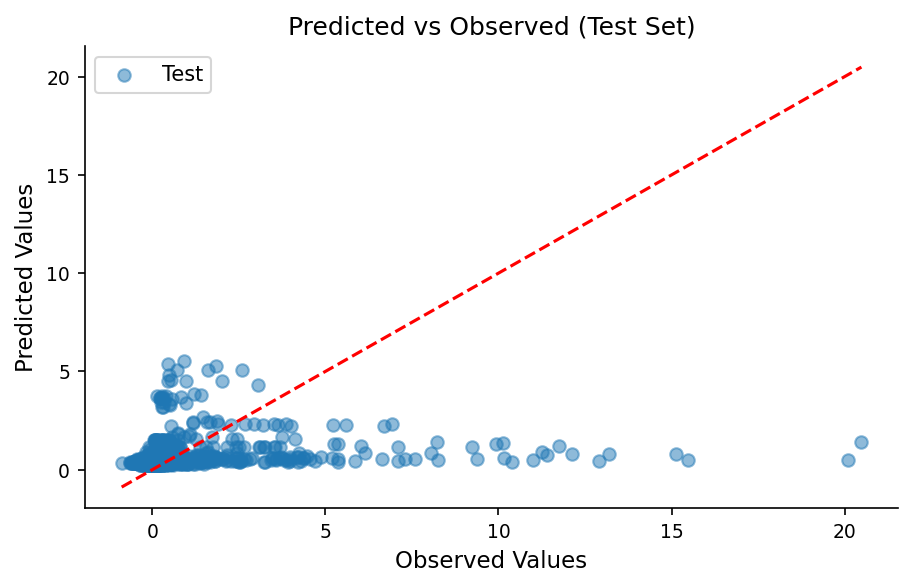

Train RMSE per fold: [1.1417 1.1877 0.7431 1.1181 1.0255]
Mean Train RMSE: 1.0432
Test RMSE per fold: [1.1279 0.7415 3.9951 1.5769 1.8297]
Mean Test RMSE: 1.8542
Train MAE per fold: [0.5204 0.5621 0.3004 0.5069 0.4827]
Mean Train MAE: 0.4745
Test MAE per fold: [0.5349 0.6479 2.1997 0.9586 0.8626]
Mean Test MAE: 1.0407
Train R² per fold: [0.7548 0.7433 0.6411 0.7642 0.7742]
Mean Train R²: 0.7355
Test R² per fold: [ -0.0343 -12.5074  -0.2715  -0.9165   0.022 ]
Mean Test R²: -2.7416


In [42]:
# Store results
rmse_train_values, rmse_test_values = [], []
mae_train_values, mae_test_values = [], []
r2_train_values, r2_test_values = [], []
feature_importances_folds = []
y_train_all, y_train_pred_all = [], []
y_test_all, y_pred_test_all = [], []

# Perform cross-validation
X = data_train.drop(columns=TARGET)
y = data_train[TARGET]
for train_idx, test_idx in cross_val_splits:  
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if LOG_TRANSFORM:
        y_train =  inverse_log_transform(y_train)
        y_test =  inverse_log_transform(y_test)
        y_train_pred =  inverse_log_transform(y_train_pred)
        y_test_pred =  inverse_log_transform(y_test_pred)

    # Store RMSE & R² for training and test sets
    rmse_train_values.append(root_mean_squared_error(y_train, y_train_pred))
    rmse_test_values.append(root_mean_squared_error(y_test, y_test_pred))
    mae_train_values.append(np.mean(np.abs(y_train - y_train_pred)))
    mae_test_values.append(np.mean(np.abs(y_test - y_test_pred)))
    r2_train_values.append(r2_score(y_train, y_train_pred))
    r2_test_values.append(r2_score(y_test, y_test_pred))

    # Store feature importances
    feature_importances_folds.append(model.feature_importances_)

    # Store predictions
    y_train_all.extend(y_train)
    y_train_pred_all.extend(y_train_pred)
    y_test_all.extend(y_test)
    y_pred_test_all.extend(y_test_pred)

# Compute mean feature importance across folds
feature_importances = np.nanmean(feature_importances_folds, axis=0)
# Sort feature importances
order = np.argsort(-feature_importances)  # Sort in descending order
feature_names = X_train.columns[order]  # Get feature names sorted by importance

# Plot sorted feature importances
fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names, feature_importances[order])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Mean Feature Importance Across Folds")
fig.tight_layout()
plt.show()

# Plot Predicted vs Observed (Training Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_train_all, y_train_pred_all, alpha=0.5, label="Train")
plt.plot([min(y_train_all), max(y_train_all)], [min(y_train_all), max(y_train_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Training Set)")
plt.legend()
plt.show()

# Plot Predicted vs Observed (Test Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_test_all, y_pred_test_all, alpha=0.5, label="Test")
plt.plot([min(y_test_all), max(y_test_all)], [min(y_test_all), max(y_test_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Test Set)")
plt.legend()
plt.show()

# Print RMSE and R² for both Training and Test sets
print(f"Train RMSE per fold: {np.array(rmse_train_values).round(4)}")
print(f"Mean Train RMSE: {np.mean(rmse_train_values):.4f}")
print(f"Test RMSE per fold: {np.array(rmse_test_values).round(4)}")
print(f"Mean Test RMSE: {np.mean(rmse_test_values):.4f}")

# Print MAE and R² for both Training and Test sets
print(f"Train MAE per fold: {np.array(mae_train_values).round(4)}")
print(f"Mean Train MAE: {np.mean(mae_train_values):.4f}")
print(f"Test MAE per fold: {np.array(mae_test_values).round(4)}")
print(f"Mean Test MAE: {np.mean(mae_test_values):.4f}")

# Print R² for both Training and Test sets
print(f"Train R² per fold: {np.array(r2_train_values).round(4)}")
print(f"Mean Train R²: {np.mean(r2_train_values):.4f}")
print(f"Test R² per fold: {np.array(r2_test_values).round(4)}")
print(f"Mean Test R²: {np.mean(r2_test_values):.4f}")


# MODEL EVALUATION

## Split train-test

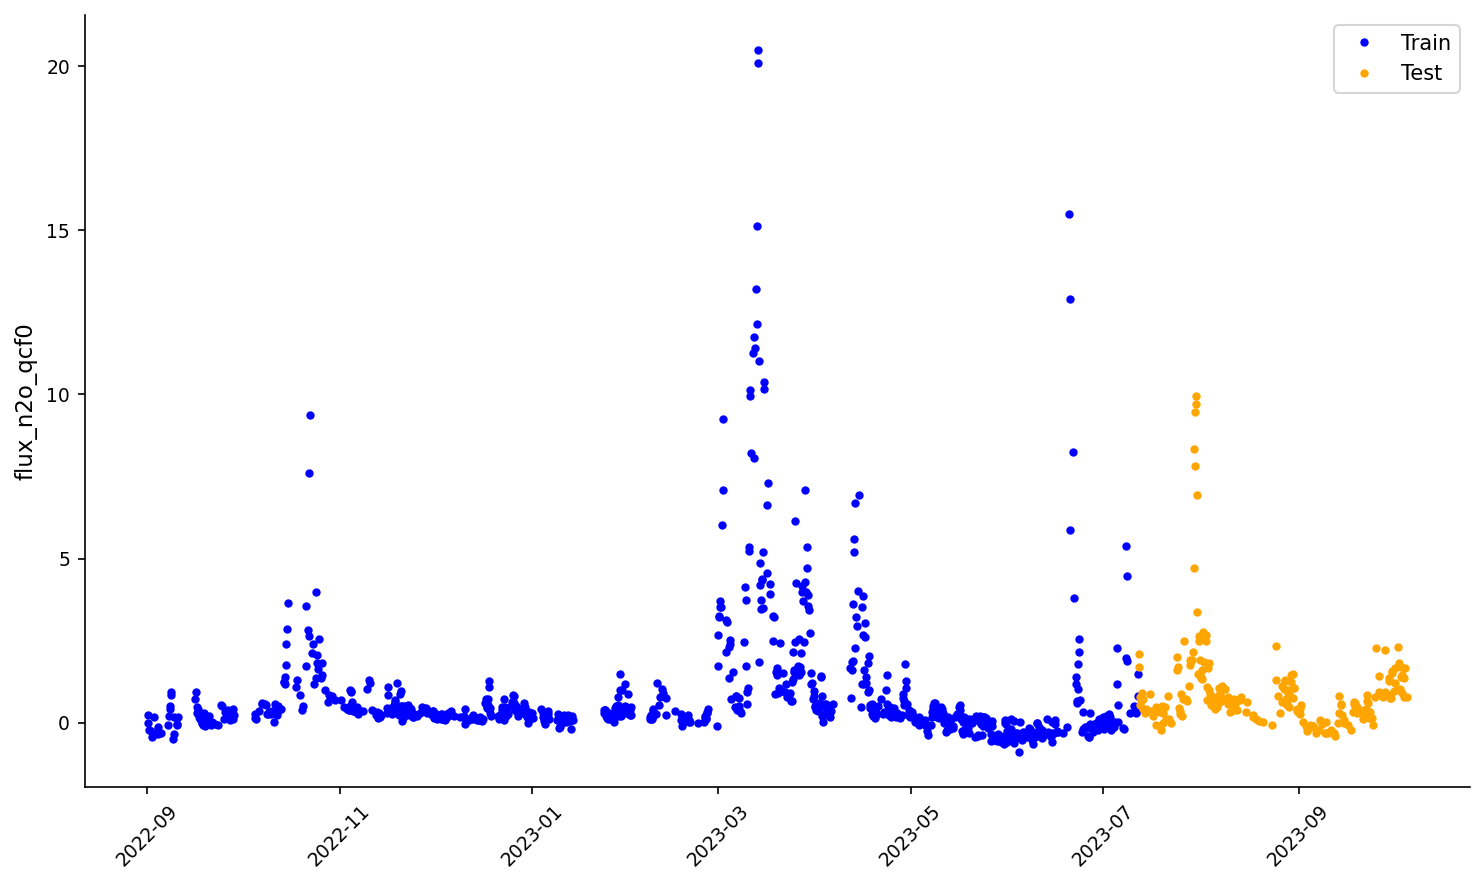

In [43]:
X_train, X_test = data_train.drop(columns=TARGET), data_test.drop(columns=TARGET)
y_train, y_test = data_train[TARGET], data_test[TARGET]
              
# Check the split
fig, ax = plt.subplots(figsize=(10, 6))  # Adjusted size for better readability
ax.plot(y_train.index, y_train, ".", label="Train", color='blue')
ax.plot(y_test.index, y_test, ".", label="Test", color='orange')
ax.set_ylabel(TARGET)
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()

# Show the plot
plt.show()

## Model training and testing

[0]	validation_0-rmse:1.48474
[1]	validation_0-rmse:1.48172
[2]	validation_0-rmse:1.47746
[3]	validation_0-rmse:1.47449
[4]	validation_0-rmse:1.47142
[5]	validation_0-rmse:1.46797
[6]	validation_0-rmse:1.46531
[7]	validation_0-rmse:1.46252
[8]	validation_0-rmse:1.45995
[9]	validation_0-rmse:1.45726
[10]	validation_0-rmse:1.45499
[11]	validation_0-rmse:1.45440
[12]	validation_0-rmse:1.45091
[13]	validation_0-rmse:1.44882
[14]	validation_0-rmse:1.44598
[15]	validation_0-rmse:1.44234
[16]	validation_0-rmse:1.44009
[17]	validation_0-rmse:1.43715
[18]	validation_0-rmse:1.43367
[19]	validation_0-rmse:1.43089
[20]	validation_0-rmse:1.42994
[21]	validation_0-rmse:1.42728
[22]	validation_0-rmse:1.42464
[23]	validation_0-rmse:1.42133
[24]	validation_0-rmse:1.41924
[25]	validation_0-rmse:1.41640
[26]	validation_0-rmse:1.41364
[27]	validation_0-rmse:1.41148
[28]	validation_0-rmse:1.40894
[29]	validation_0-rmse:1.40625
[30]	validation_0-rmse:1.40332
[31]	validation_0-rmse:1.40158
[32]	validation_0-

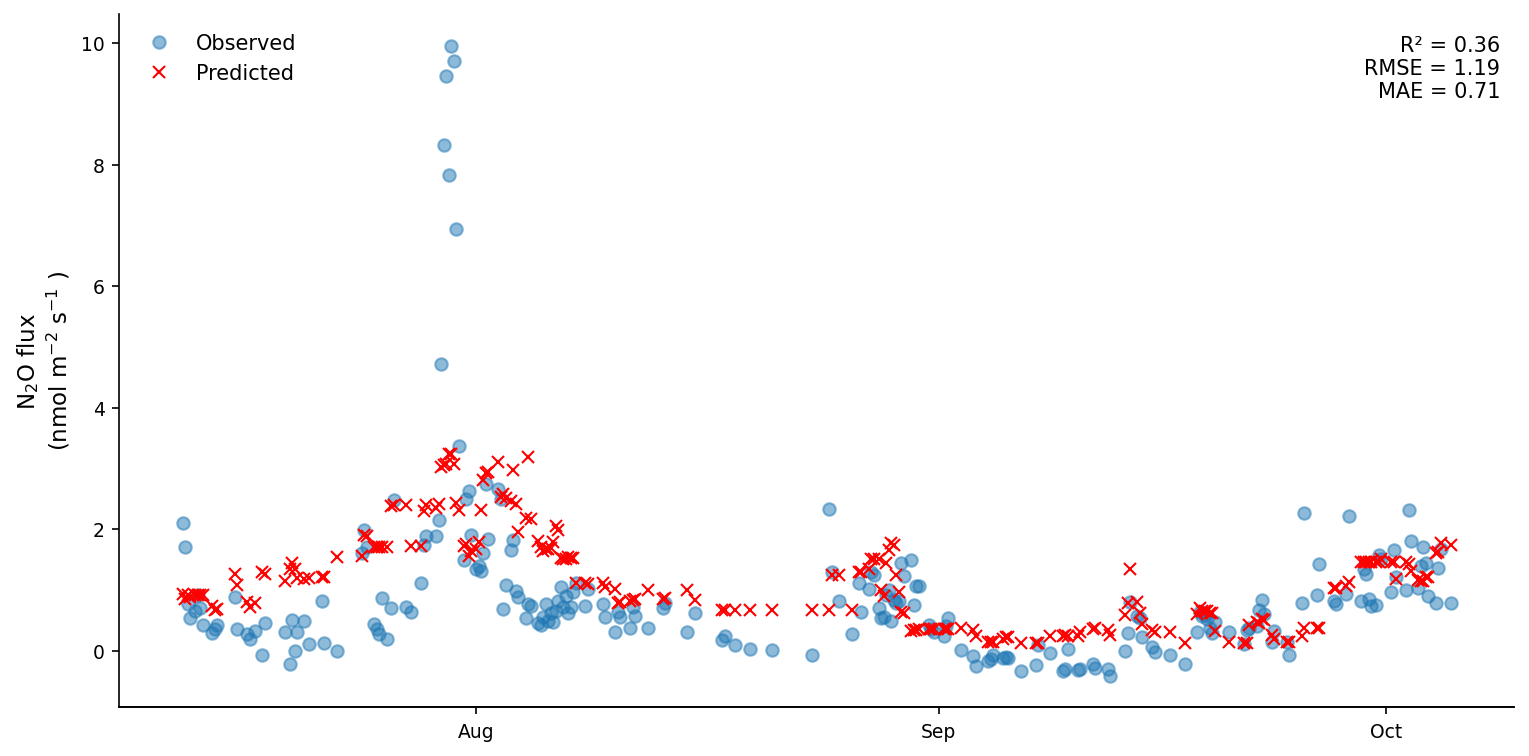

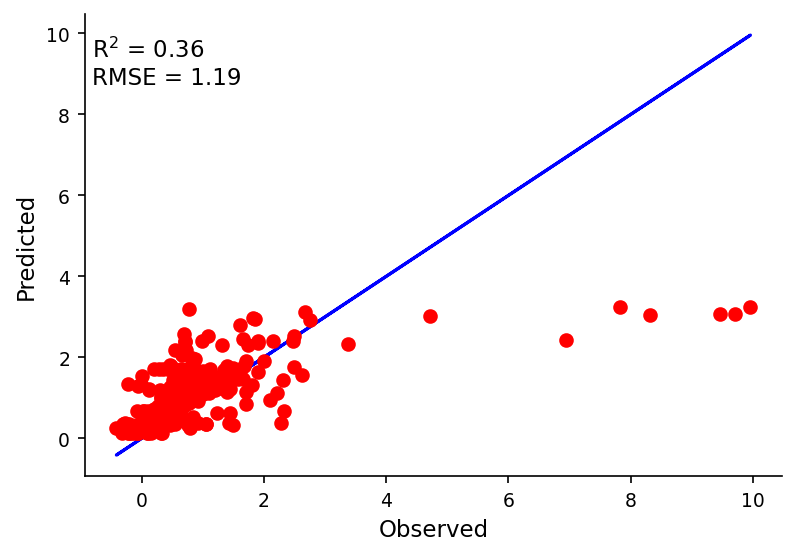

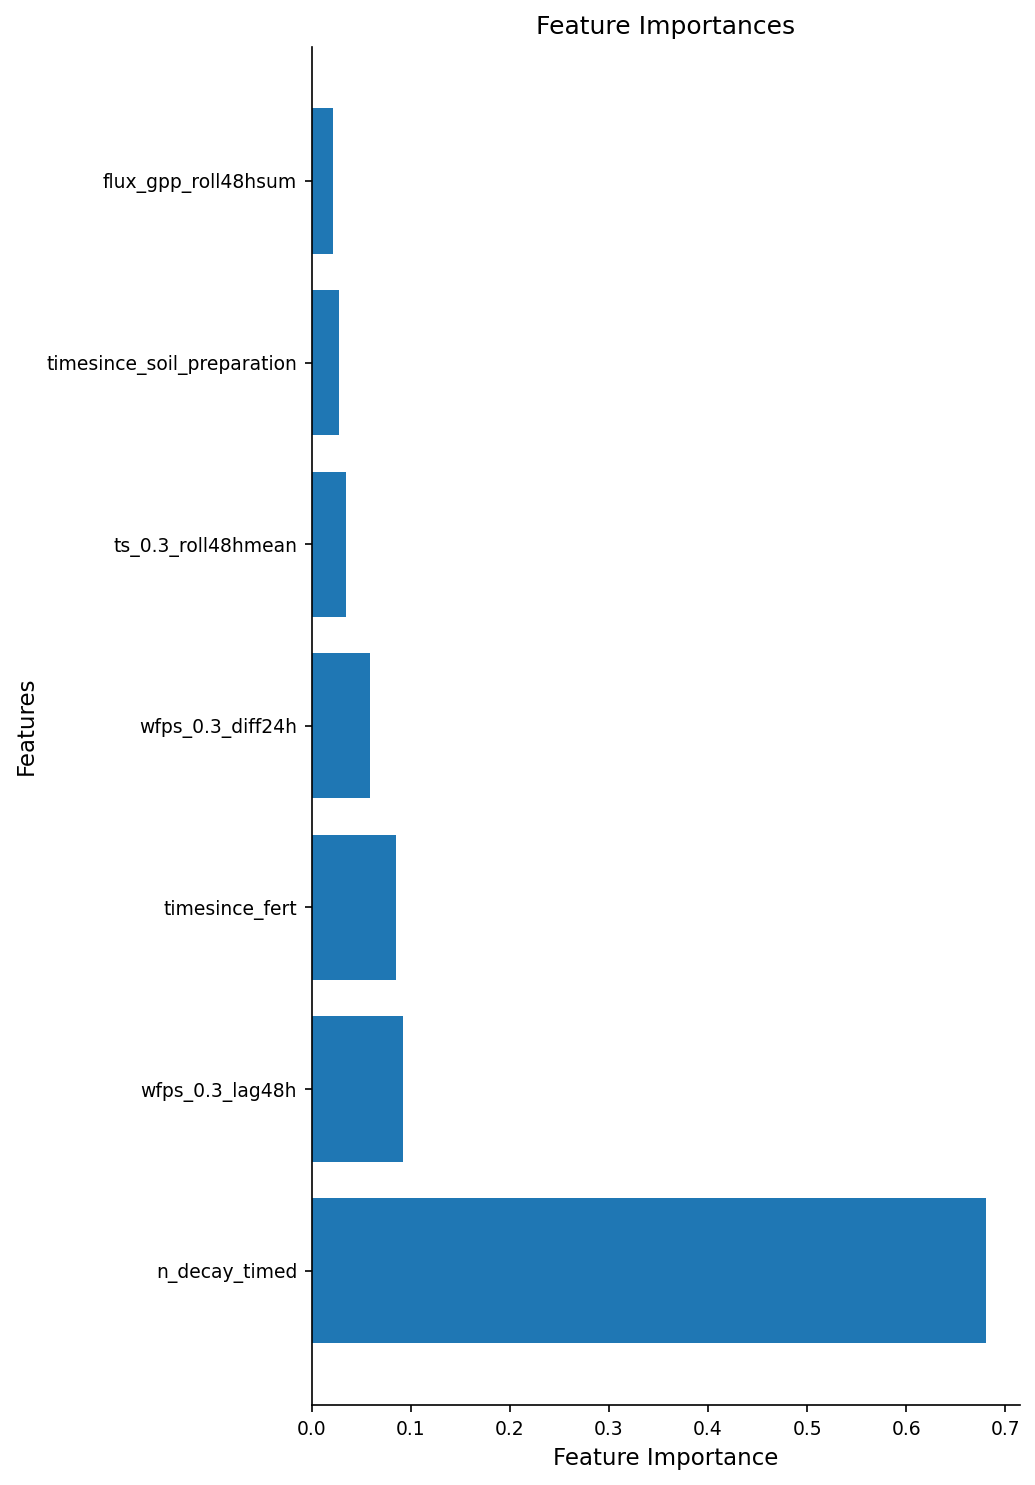

In [71]:
# Predict test set
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

# Reverse the log transformation on the predictions and the original transformed data when the transformation was used
if LOG_TRANSFORM:
    pred_train = inverse_log_transform(pred_train) 
    pred_test = inverse_log_transform(pred_test)
    y_train = inverse_log_transform(y_train)
    y_test = inverse_log_transform(y_test)

# Calculate performance metrics for the training set
r2_train = r2_score(y_train, pred_train)
print(f"R-squared (Training set): {r2_train:.4f}")
rmse_train = root_mean_squared_error(y_train, pred_train)
print(f"Root Mean Squared Error (Training set): {rmse_train:.4f}")
mae_train = np.mean(np.abs(y_train - pred_train))
print(f"Mean Absolute Error (Training set): {mae_train:.4f}")
# Calculate performance metrics for the test set
r2_test = r2_score(y_test, pred_test)
print(f"R-squared (Test set): {r2_test:.4f}")
rmse_test = root_mean_squared_error(y_test, pred_test)
print(f"Root Mean Squared Error (Test set): {rmse_test:.4f}")
mae_test = np.mean(np.abs(y_test - pred_test))
print(f"Mean Absolute Error (Test set): {mae_test:.4f}")

# Time series plot
fig, ax = plt.subplots(1,figsize=(12, 6))
ax.plot(y_test.index, y_test,"o",label=("Observed"), alpha=0.5)
ax.plot(y_test.index, pred_test,"rx",label=("Predicted"))
# Format x-axis for months
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Major ticks for months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as month abbreviation
# Add secondary x-axis for years
secax = ax.secondary_xaxis('bottom')
secax.xaxis.set_major_locator(mdates.YearLocator())  # Year ticks
secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format as year
secax.tick_params(axis='x', length=0, pad=30)  # Add padding for better readability
# Add R2 and RMSE text
ax.text(0.99, 0.97, f'R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}\nMAE = {mae_test:.2f}',
        transform=ax.transAxes, va='top', ha='right')
ax.set_ylabel('N$_2$O flux\n(nmol m$^{-2}$ s$^{-1}$ )')
ax.legend(frameon=False, loc="upper left")
# save fig
plt.savefig('../figures/model_performance_test.png', dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Obs Vs predicted
fig, ax = plt.subplots(1,figsize=(6,4))
ax.plot(y_test,y_test,"b-")
ax.plot(y_test,pred_test,"ro")
# Add R2 and RMSE text
ax.text(0.01, 0.95, f'R$^{2}$ = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', fontsize=11)
ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
plt.show()

# Plot feature importances
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # Sort descending
feature_names_sorted = X_train.columns[sorted_idx]

fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names_sorted, importances[sorted_idx])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Feature Importances")
plt.tight_layout()
plt.show()

# SHAP ANALYSIS

## TRAIN MODEL

R-squared (Entire dataset): 0.7544
Mean Absolute Error (Entire dataset): 0.4612
Root Mean Squared Error (Entire dataset): 0.9976


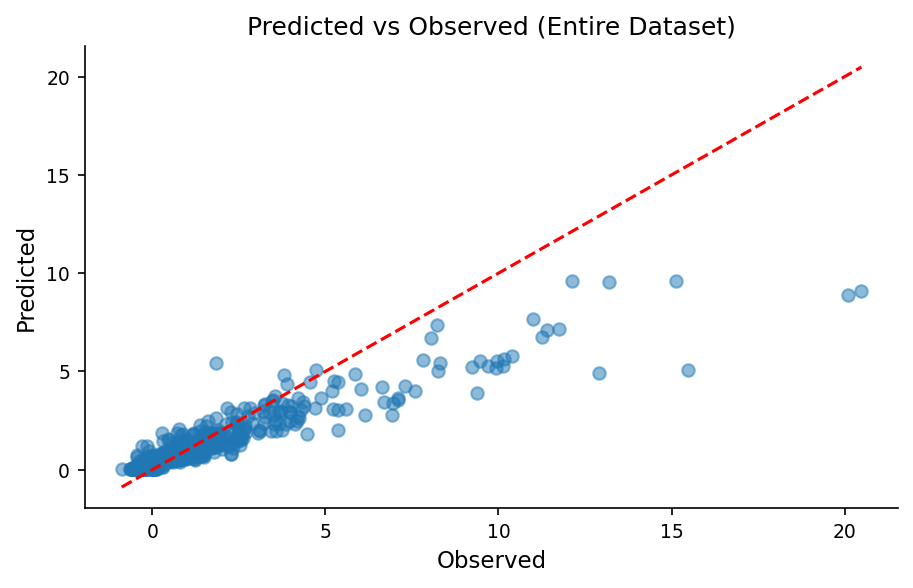

In [70]:
# refit the model on the entire dataset for SHAP analysis
X = data[selected_features]
y = data[TARGET]  # Ensure no NAs in the target variable for fitting
model.fit(X, y)

# Calculate performance metrics for the entire dataset
pred_all = model.predict(X)
r2_all = r2_score(y, pred_all)
mae_all = np.mean(np.abs(y - pred_all))
rmse_all = root_mean_squared_error(y, pred_all)
print(f"R-squared (Entire dataset): {r2_all:.4f}")
print(f"Mean Absolute Error (Entire dataset): {mae_all:.4f}")
print(f"Root Mean Squared Error (Entire dataset): {rmse_all:.4f}")

# Plot Predicted vs Observed (Entire Dataset)
plt.figure(figsize=(7, 4))
plt.scatter(y, pred_all, alpha=0.5)
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--')
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Predicted vs Observed (Entire Dataset)")
plt.show()

## RUN SHAP

In [ ]:
# define background dataset as undisturbed conditions (fertilization and soil preparation >= 30 days)
cols = [
    'timesince_soil_preparation', 
    'timesince_fert'
    ]
background_dataset = data_complete.loc[data_complete[cols].eq(30).all(axis=1), selected_features]
#background_dataset = data_complete[selected_features]

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(model, data=background_dataset)

# Calculate SHAP values for the entire dataset
X = data_complete[selected_features]
shap_values = explainer(X, check_additivity=True)

# Print the expected value
print("Baseline (expected value):", explainer.expected_value)
if LOG_TRANSFORM:
    print("Baseline without transformation (expected value):", inverse_log_transform(explainer.expected_value))

100%|===================| 2392/2398 [00:35<00:00]        

Baseline (expected value): 0.4499738700709032


## SUMMARY PLOT

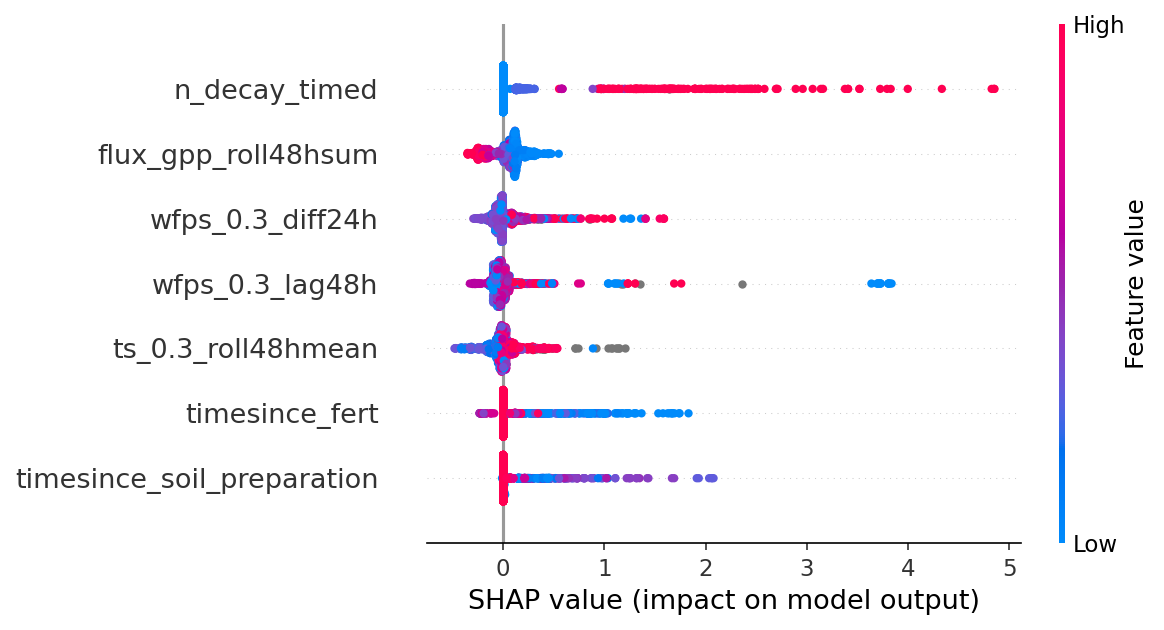

In [48]:
# SHAP summary plot
fig = plt.figure()
shap.summary_plot(shap_values, X, show=False)
# Save the figure
fig.savefig('../figures/shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## Restructure dataframe

In [49]:
# Convert SHAP values to a DataFrame
shap_df = pd.DataFrame(
    data=shap_values.values,  # SHAP values
    index=X.index,  # Use the index of X
    columns=X.columns  # Use feature names as columns
)

# Pool together fertilization variables
fertilization_cols = [col for col in shap_df.columns if col.startswith('n_decay') or 'fert' in col]
shap_df['fertilization'] = shap_df[fertilization_cols].sum(axis=1)
shap_df.drop(columns=fertilization_cols, inplace=True)

# Pool together WFPS variables
wfps_cols = [col for col in shap_df.columns if col.startswith('wfps')]
shap_df['wfps'] = shap_df[wfps_cols].sum(axis=1)
shap_df.drop(columns=wfps_cols, inplace=True)

# Rename DataFrame columns
rename_dict = {
    next(c for c in shap_df.columns if 'fertilization' in c): 'N fertilization',
    next(c for c in shap_df.columns if 'gpp' in c): 'GPP',
    next(c for c in shap_df.columns if 'wfps' in c): 'WFPS',
    next(c for c in shap_df.columns if 'timesince_soil_preparation' in c): 'Soil disturbance',
    next(c for c in shap_df.columns if 'ts' in c): 'Soil T',
}

# Identify columns to keep and others to aggregate
key_cols = list(rename_dict.keys())
other_cols = [col for col in shap_df.columns if col not in key_cols]
# Rename key columns
shap_df.rename(columns=rename_dict, inplace=True)
# Arbitrary column order
col_order = ['N fertilization', 'WFPS', 'GPP', 'Soil disturbance', 'Soil T']
shap_df = shap_df[col_order]

## Normalization and aggregation

In [50]:
# Create a normalized version of shap values
shap_df_norm = shap_df.div(
    shap_df.abs().sum(axis=1), axis=0
)

# Aggregate SHAP values 
aggregation_period = 'D'
shap_df_agg = shap_df.resample(aggregation_period).mean()
shap_df_agg_norm = shap_df_agg.div(
    shap_df_agg.abs().sum(axis=1), axis=0
)

shap_df_agg_norm

,N fertilization,WFPS,GPP,Soil disturbance,Soil T
timestamp_middle,,,,,
2022-09-01,0.000000,-0.730739,-0.008940,0.000000,0.260320
2022-09-02,0.000000,-0.895966,0.025780,0.000000,-0.078254
2022-09-03,0.000000,-0.828175,0.025156,0.000000,-0.146669
2022-09-04,0.000000,-0.798857,0.066955,0.000000,-0.134187
2022-09-05,0.000000,0.456671,-0.354995,0.000000,-0.188334
...,...,...,...,...,...
2023-10-01,0.000000,-0.083773,0.322107,0.477810,0.116310
2023-10-02,0.000000,-0.079215,0.326313,0.478258,0.116214
2023-10-03,0.000000,-0.112506,0.304322,0.473252,0.109920


## TIME-SERIES PLOTS

### Stacked bar plot

Plotting configs

In [51]:
# Define the shading time window
highlight_start = pd.Timestamp('2022-10-06')
highlight_end = pd.Timestamp('2023-07-15')

# Define labels and colors for the management events
event_lines = [
    {'date': '2022-10-06', 'color': '#003366', 'linestyle': ':', 'label': 'sowing'},
    {'date': '2023-07-15', 'color': '#003366', 'linestyle': '--', 'label': 'harvest'}, # wheat harvest
    {'date': '2023-02-26', 'color': '#F2C744', 'linestyle': '-', 'label': None},
    {'date': '2023-02-28', 'color': '#F2C744', 'linestyle': '-', 'label': 'N fert'},
    {'date': '2023-04-06', 'color': '#F2C744', 'linestyle': '-', 'label': 'N fert'},  # second mineral fert
]

# Improved color-blind–friendly palette
palette = [
    '#882255',
    '#0072B2', 
    '#009E73',  
    '#A6761D',
    '#FDAE61'   
]

Prep input data

In [52]:
# Measured FN2O
fn2o_agg = data_main[TARGET].resample(aggregation_period).mean()

# Predicted FN2O
preds = model.predict(X)
fn2o_preds = pd.Series(preds, index=shap_df.index)
if LOG_TRANSFORM:
    fn2o_preds = inverse_log_transform(fn2o_preds)
fn2o_preds_agg = fn2o_preds.resample(aggregation_period).mean()

# Daily GPP
gpp_agg = data_main['flux_gpp'].resample(aggregation_period).mean()

#### plotting functions

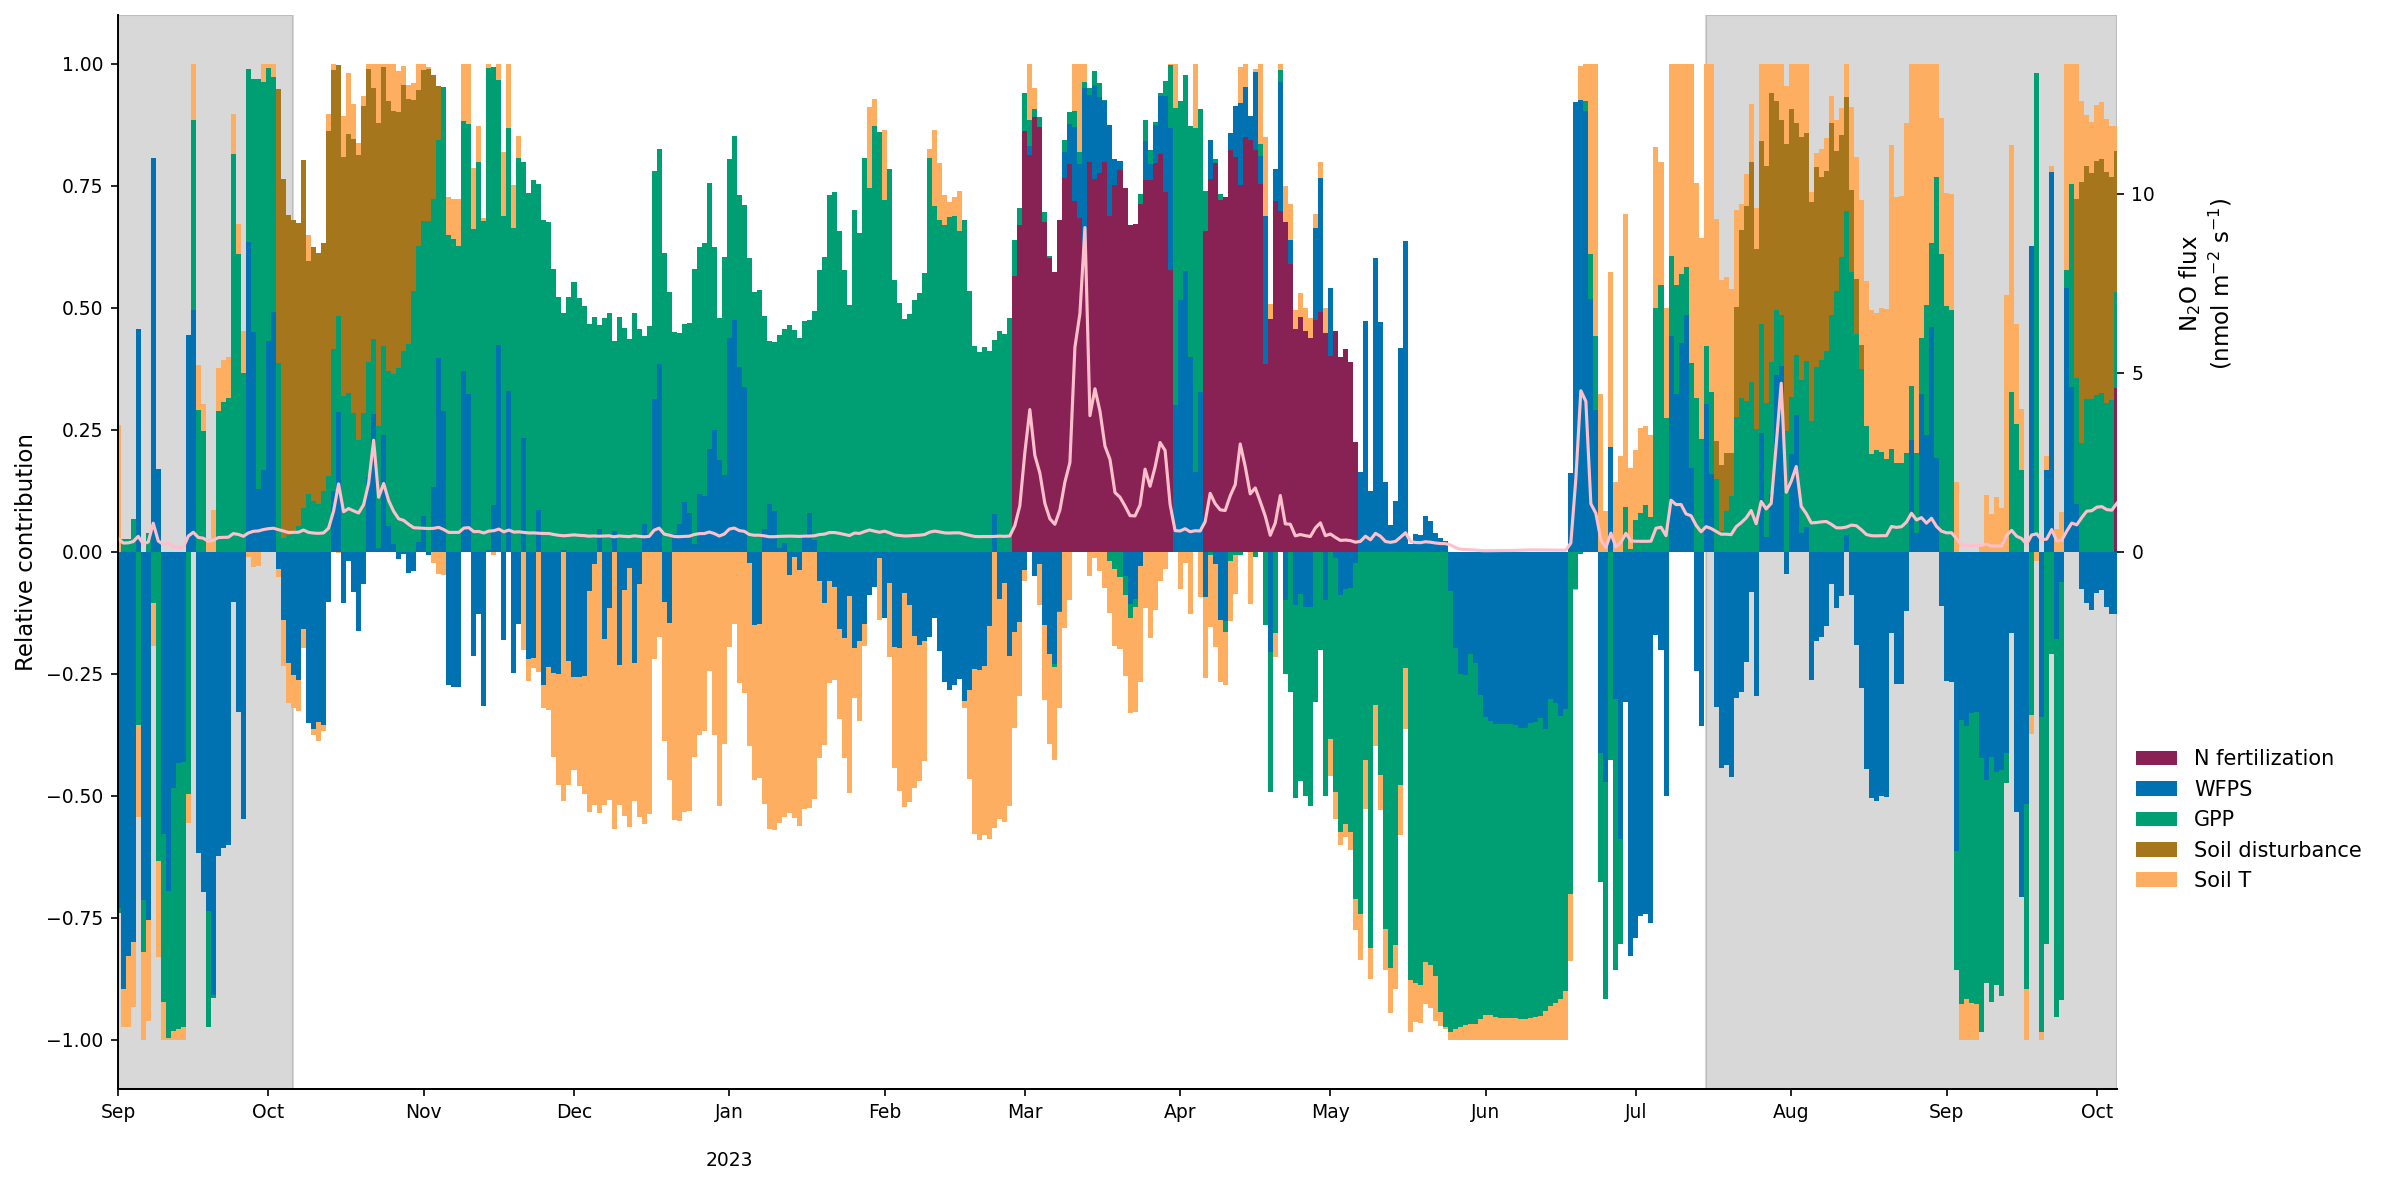

In [53]:
def plot_shap_timeseries(df, shading=True, fn2o_observed=None, fn2o_predicted=None, width=1, start_date=None, end_date=None, ax1=None, ax2=None):

    # Filter data if date range is provided
    if start_date or end_date:
        df = df.loc[start_date:end_date]
        if fn2o_observed is not None:
            fn2o_observed = fn2o_observed.loc[start_date:end_date]
        if fn2o_predicted is not None:
            fn2o_predicted = fn2o_predicted.loc[start_date:end_date]

    # Split SHAP values into positive and negative contributions
    shap_df_pos = df.clip(lower=0)
    shap_df_neg = df.clip(upper=0)

    # Plot SHAP positive contributions
    bottom_pos = None
    for idx, column in enumerate(shap_df_pos.columns):
        ax1.bar(
            shap_df_pos.index,
            shap_df_pos[column],
            bottom=bottom_pos,
            label=column,
            color=palette[idx],
           width=width
        )
        bottom_pos = shap_df_pos[column] if bottom_pos is None else bottom_pos + shap_df_pos[column]

    # Plot SHAP negative contributions
    bottom_neg = None
    for idx, column in enumerate(shap_df_neg.columns):
        ax1.bar(
            shap_df_neg.index,
            shap_df_neg[column],
            bottom=bottom_neg,
            label=None,
            color=palette[idx],
            width=width
        )
        bottom_neg = shap_df_neg[column] if bottom_neg is None else bottom_neg + shap_df_neg[column]

    # Add shading to highlight a certain time window
    if shading:
        ax1.axvspan('2022-09-01', highlight_start, color='gray', alpha=0.3, zorder=0)
        ax1.axvspan(highlight_end, df.index.max(), color='gray', alpha=0.3, zorder=0)

    # Secondary y-axis for fn2o
    ax2 = None
    if fn2o_observed is not None or fn2o_predicted is not None:
        ax2 = ax1.twinx()
    if fn2o_observed is not None:
        ax2.plot(fn2o_observed.index, fn2o_observed, color='white', marker='x', linestyle='none',
                alpha=1, linewidth=1.5, label='measured N$_2$O flux')
    if fn2o_predicted is not None:
        ax2.plot(fn2o_predicted.index, fn2o_predicted, color='pink', linestyle='-',
                alpha=1, linewidth=1.5,
#                label='predicted N$_2$O flux'
                )

    # Format y axis
    ax1.set_ylim(-1.1, 1.1)
    if ax2 is not None:
        y2_max = 15
        ax2.set_ylim(-y2_max, y2_max)
        ax2.set_yticks([tick for tick in ax2.get_yticks() if tick >= 0 and tick <= 10])
    
    # Labels and legends
    ax1.set_ylabel("Relative contribution")
    if ax2 is not None:    
        ax2.set_ylabel("N$_2$O flux\n(nmol m$^{-2}$ s$^{-1}$)")
        ax2.yaxis.set_label_coords(1.03, 0.75)  # set new vertical (y) position
    ax1.legend(bbox_to_anchor=(1, 0.25), frameon=False, loc="center left")

    # Format x-axis for months
    ax1.xaxis.set_major_locator(mdates.MonthLocator())  # Major ticks for months
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as month abbreviation

    # Add secondary x-axis for years
    secax = ax1.secondary_xaxis('bottom')
    secax.xaxis.set_major_locator(mdates.YearLocator())  # Year ticks
    secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format as year
    secax.tick_params(axis='x', length=0, pad=30)  # Add padding for better readability

    # Set x-axis limits to match data range --> to prevent white spaces
    ax1.set_xlim(df.index.min(), df.index.max())
    if ax2 is not None:
        ax2.set_xlim(df.index.min(), df.index.max())
    
    return ax1, ax2

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
ax, ax_twin = plot_shap_timeseries(df=shap_df_agg_norm, fn2o_predicted=fn2o_preds_agg, ax1=ax, width=1)
plt.tight_layout()
plt.show()

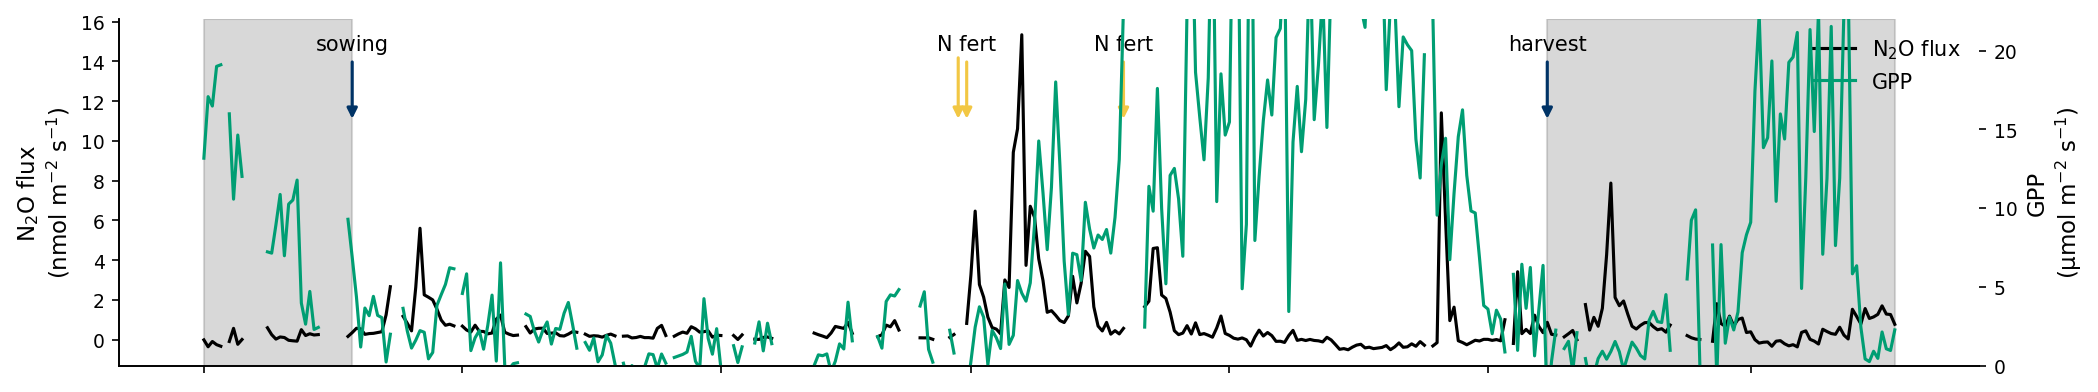

In [54]:
def plot_flux_timeseries(flux_1, flux_2, linestyle='-', linewidth=3,
                         figsize=(12, 4), ax=None, scale_gpp=1/2):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Primary y-axis: N2O
    ax.plot(flux_1.index, flux_1.values, color='black', linestyle=linestyle,
            alpha=1, linewidth=linewidth, label='N$_2$O flux')

    # Secondary y-axis: GPP
    ax2 = ax.twinx()

    # Plot rescaled GPP data
    ax2.plot(flux_2.index, flux_2.values * scale_gpp, color='#009E73', linestyle=linestyle,
             alpha=1, linewidth=linewidth, label='GPP')
    
    # Set ticks for GPP
    true_ticks = np.arange(0, 21, 5)
    ax2.set_yticks(true_ticks * scale_gpp)            # positions (scaled)
    ax2.set_yticklabels([str(t) for t in true_ticks]) # real values
    ax2.set_ylim(0 * scale_gpp, 22 * scale_gpp)       # lock axis
    ax2.set_ylabel("GPP\n(µmol m$^{-2}$ s$^{-1}$)")

    # Annotate management events
    for event in event_lines:
        event_date = pd.to_datetime(event['date'])
        ax.annotate(
            text=event['label'],
            xy=(mdates.date2num(event_date), 0.7),
            xytext=(mdates.date2num(event_date), 0.9),
            xycoords=('data', 'axes fraction'),
            textcoords=('data', 'axes fraction'),
            ha='center',
            va='bottom',
            color='black',
            arrowprops=dict(
                arrowstyle='-|>',
                color=event['color'],
 #               linestyle=event['linestyle'],
                lw=1.5
            ),
            annotation_clip=False
        )

    # Add shading to highlight a certain time window
    ax.axvspan('2022-09-01', highlight_start, color='gray', alpha=0.3, zorder=0)
    ax.axvspan(highlight_end, flux_1.index.max(), color='gray', alpha=0.3, zorder=0)

    # Labels and legends
    ax.set_ylabel("N$_2$O flux\n(nmol m$^{-2}$ s$^{-1}$)")
    ax.tick_params(axis='x', bottom=True, labelbottom=False)

    # Combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=False)

    return ax

fig, ax = plt.subplots(figsize=(16, 3))
# Plot normalized SHAP
plot_flux_timeseries(fn2o_agg, gpp_agg, ax=ax, linewidth=1.5)
plt.show()

#### normalized

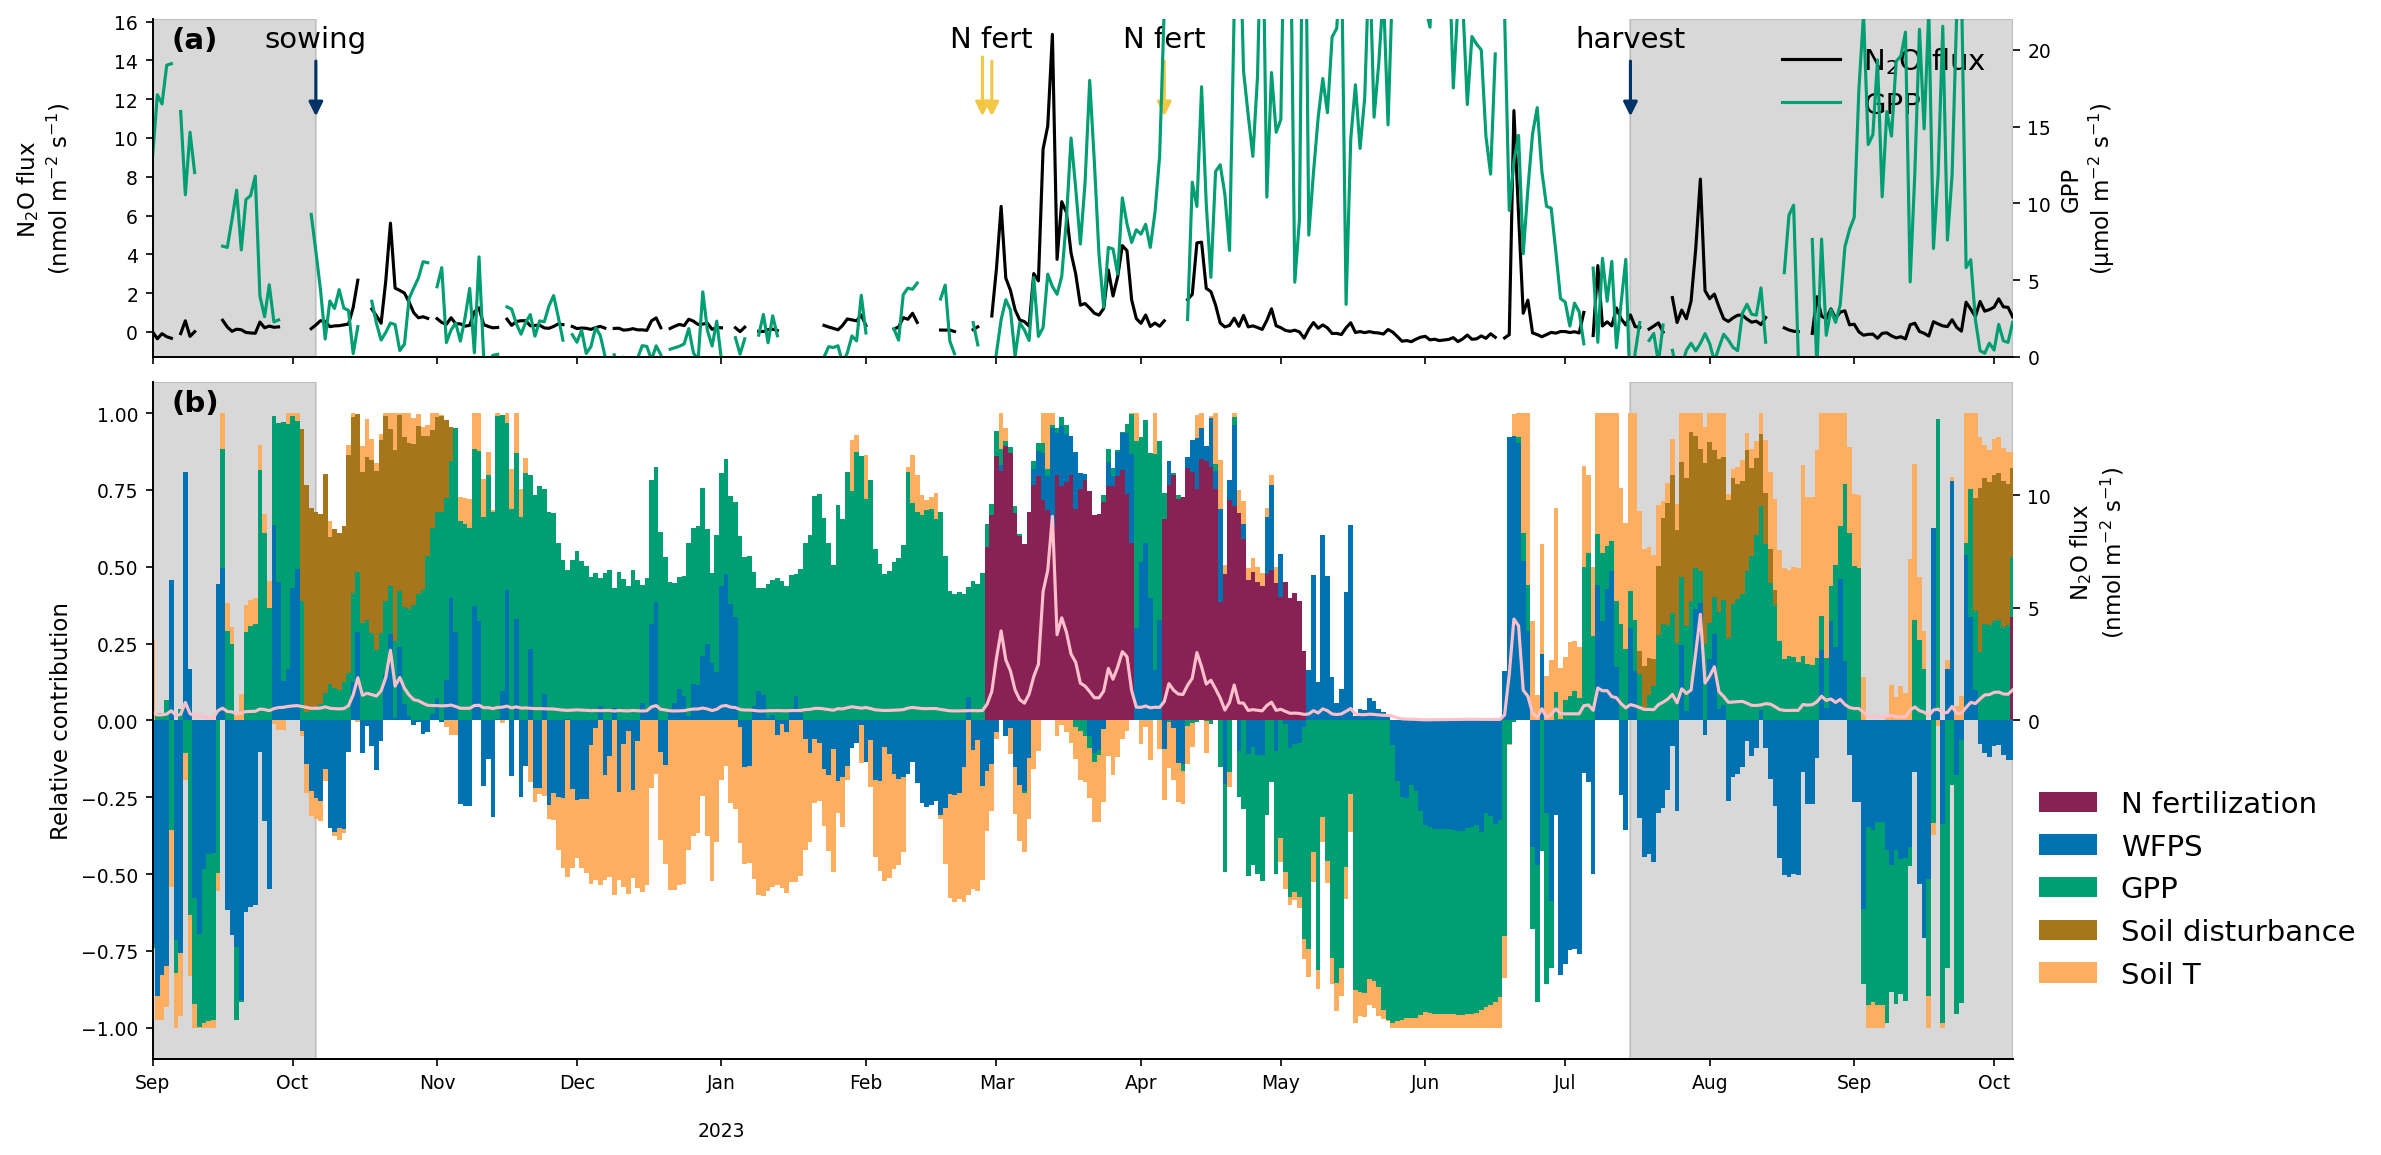

In [55]:
# Plot
plt.rcParams.update({'font.size': 14})  # Set global font size to 12 pt
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(nrows=2, ncols=1, height_ratios=[1, 2], hspace=0.05, wspace=0.05)
# Create subplots
ax_flux = fig.add_subplot(gs[0])    # Add subplot label 
ax_shap = fig.add_subplot(gs[1], sharex=ax_flux)
# Add letters to subplots
ax_flux.text(0.01, 0.98, '(a)', transform=ax_flux.transAxes, fontweight='bold', verticalalignment='top')
ax_shap.text(0.01, 0.99, '(b)', transform=ax_shap.transAxes, fontweight='bold', verticalalignment='top')
# Call plotting functions
plot_flux_timeseries(fn2o_agg, gpp_agg, ax=ax_flux, linewidth=1.5)
plot_shap_timeseries(df=shap_df_agg_norm, fn2o_predicted=fn2o_preds_agg, ax1=ax_shap, width=1)
# Align y-axis labels
fig.align_ylabels(fig.axes)
# save fig
plt.savefig('../figures/shap_stacked_bar_normalized.png', dpi=300, bbox_inches="tight")
plt.show()

#### standard

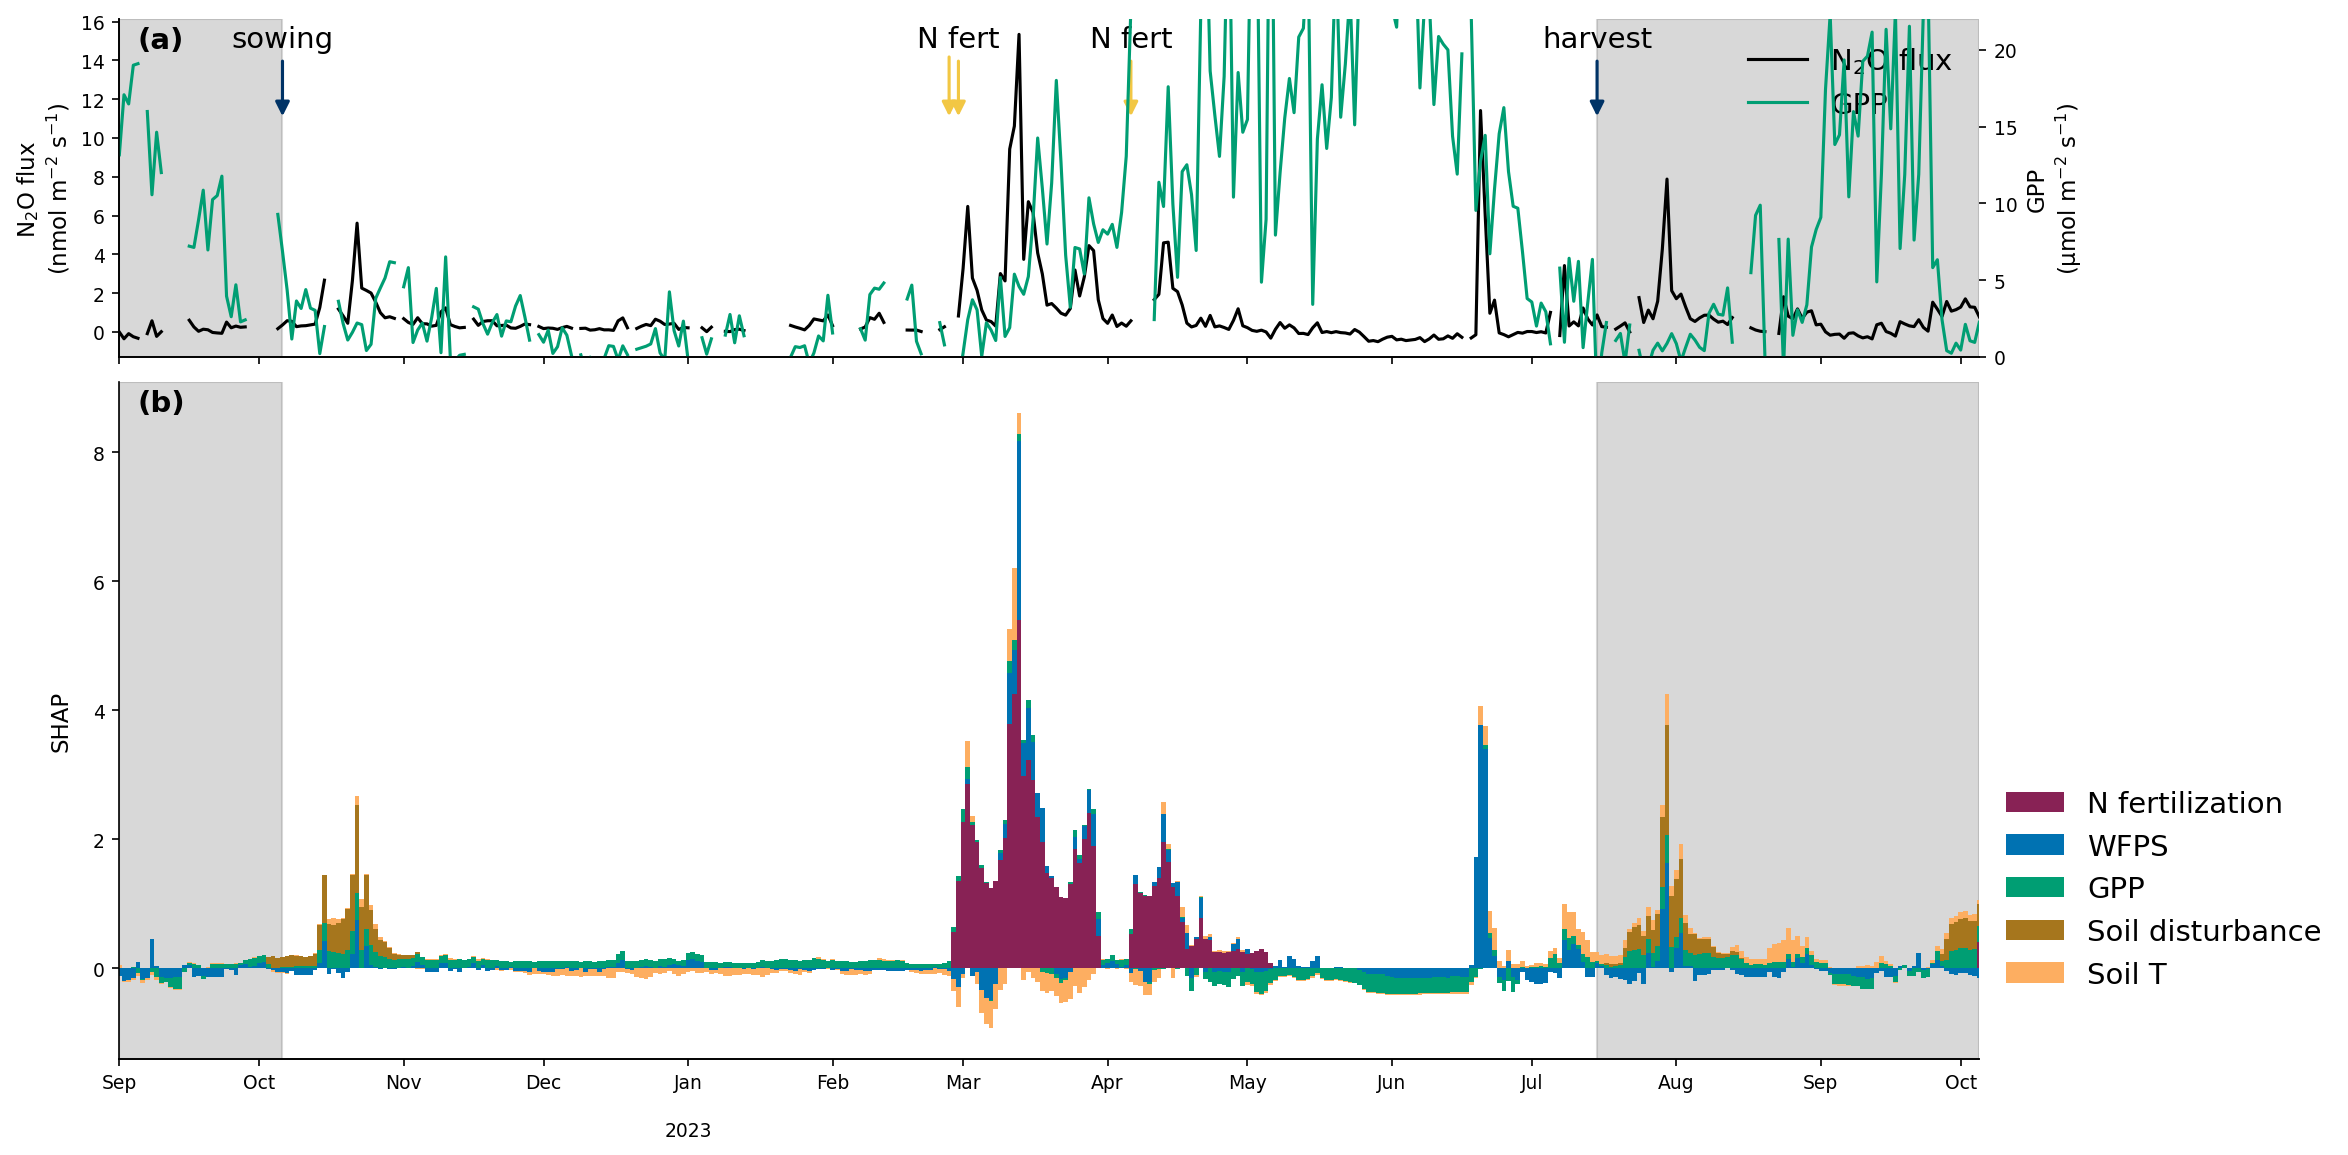

In [56]:
# Plot
plt.rcParams.update({'font.size': 14})  # Set global font size to 12 pt
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(nrows=2, ncols=1, height_ratios=[1, 2], hspace=0.05, wspace=0.05)
# Create subplots
ax_flux = fig.add_subplot(gs[0])
ax_shap = fig.add_subplot(gs[1], sharex=ax_flux)
# Add letters to subplots
ax_flux.text(0.01, 0.98, '(a)', transform=ax_flux.transAxes, fontweight='bold', verticalalignment='top')
ax_shap.text(0.01, 0.99, '(b)', transform=ax_shap.transAxes, fontweight='bold', verticalalignment='top')
# Call plotting functions
plot_flux_timeseries(fn2o_agg, gpp_agg, ax=ax_flux, linewidth=1.5)
plot_shap_timeseries(df=shap_df_agg, ax1=ax_shap, width=1)
# Allow autoscale for y axis to show the full range
ax_shap.autoscale(axis='y')
# Rename y axis title
ax_shap.set_ylabel("SHAP")
# Align y-axis labels
fig.align_ylabels(fig.axes)
# save fig
plt.savefig('../figures/shap_stacked_bar_standard.png', dpi=300, bbox_inches="tight")
plt.show()

### Heatmap plot

#### plotting functions

In [57]:
def plot_shap_heatmap(shap_df, cmap='coolwarm', figsize=(16, 6), label='Relative contribution', ax=None, cax=None):

    shap_df = shap_df.copy()
    shap_df = shap_df[shap_df.columns[::-1]]  # reverse feature columns to have in the plot the most important on top
    dates = shap_df.index
    features = shap_df.columns
    data = shap_df.T.values 
    date_nums = mdates.date2num(dates)

    # Create mesh grid for pcolormesh (1 extra on each side)
    X, Y = np.meshgrid(
        np.append(date_nums, date_nums[-1] + 1),
        np.arange(len(features) + 1)
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()
    
    pcm = ax.pcolormesh(X, Y, data, cmap=cmap, shading='auto',
                        vmin=-np.max(np.abs(data)), vmax=np.max(np.abs(data)))
    
    ax.set_yticks(np.arange(len(features)) + 0.5)
    ax.set_yticklabels(features)
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    secax = ax.secondary_xaxis('bottom')
    secax.xaxis.set_major_locator(mdates.YearLocator())
    secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    secax.tick_params(axis='x', length=0, pad=30)
    
    if cax is not None:
        fig.colorbar(pcm, cax=cax, label=label)
    else:
        fig.colorbar(pcm, ax=ax, label=label)

    return ax

#ax = plot_shap_heatmap(shap_df_norm)

#### normalized

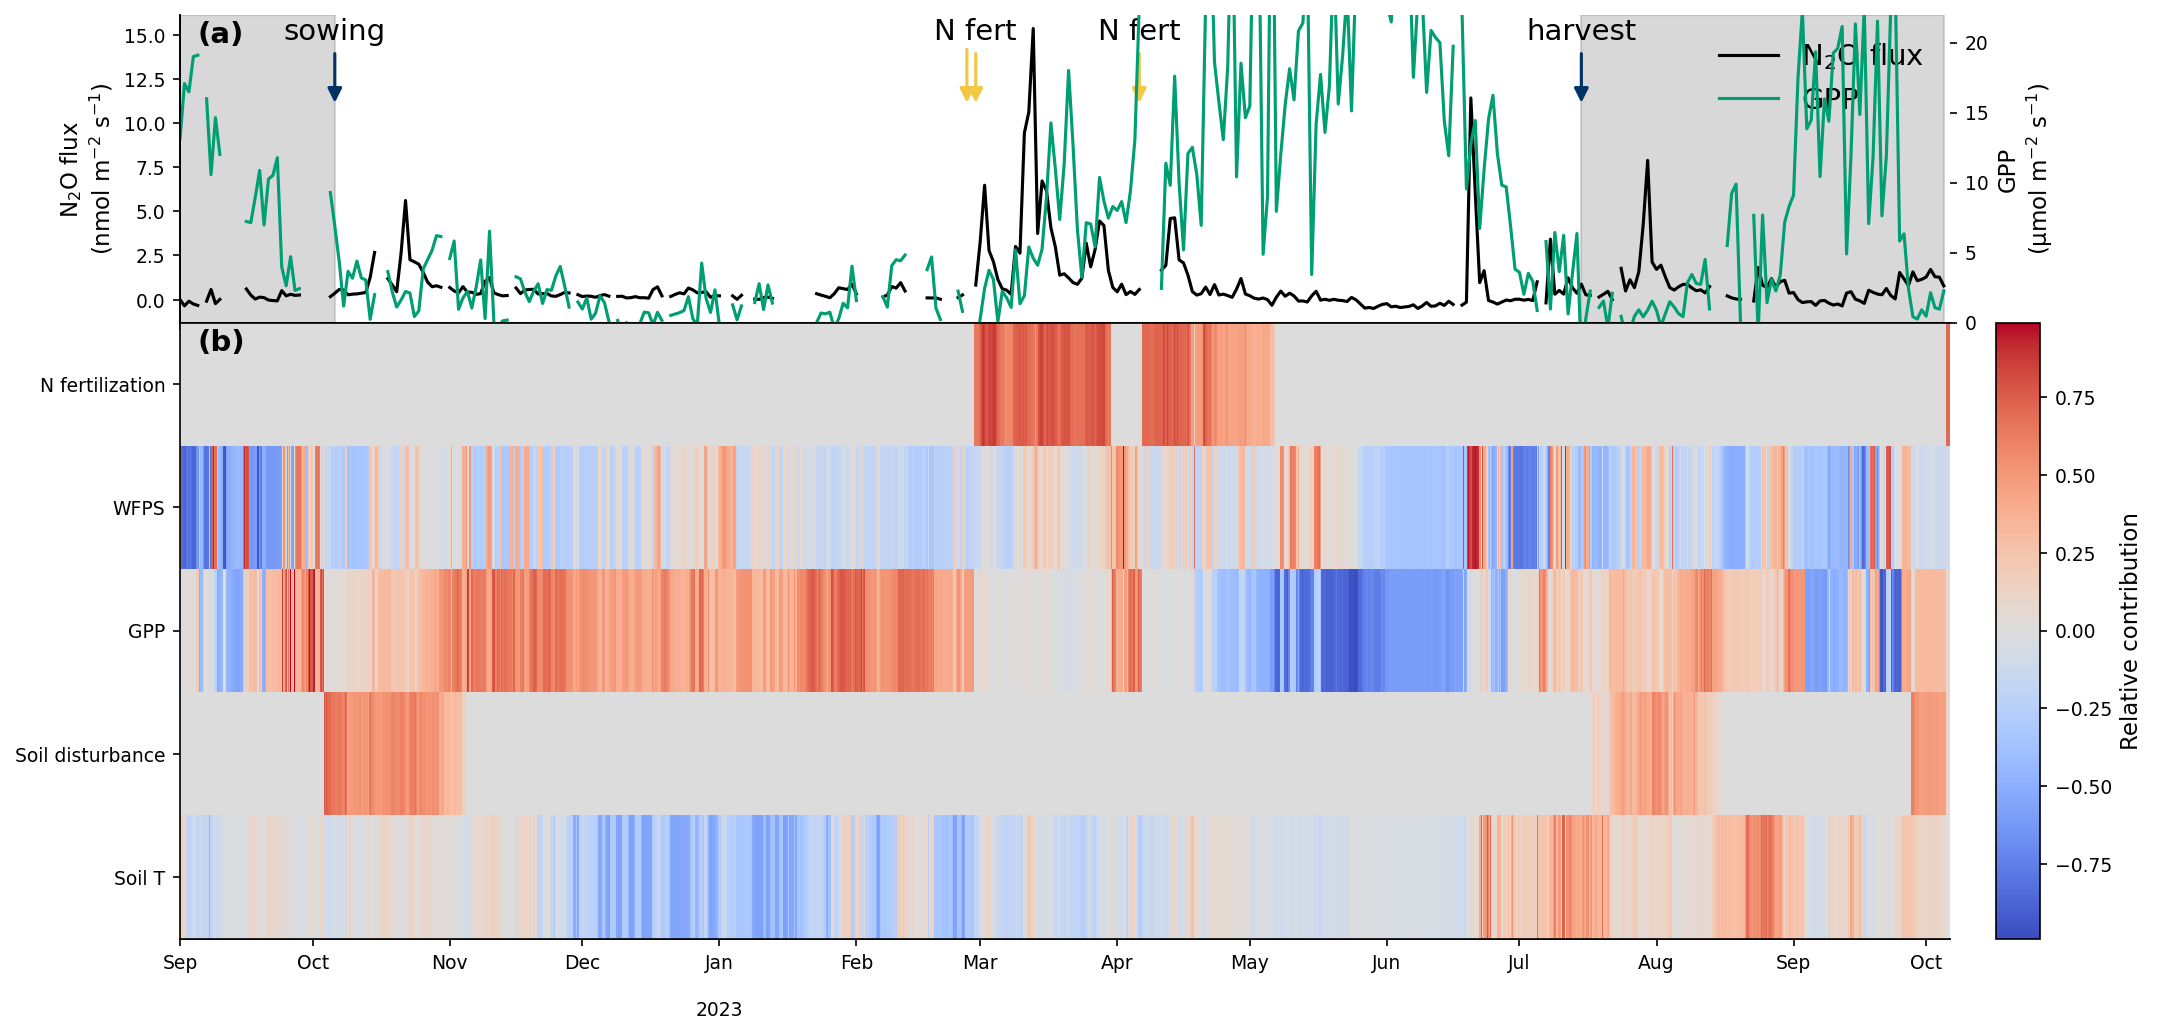

In [58]:
# Create figure with 2 rows, 2 columns (second column for SHAP colorbar)
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(nrows=2, ncols=2, width_ratios=[20, 0.5], height_ratios=[1, 2], hspace=0, wspace=0.05)

# Create subplots
ax_flux = fig.add_subplot(gs[0, 0])
ax_shap = fig.add_subplot(gs[1, 0], sharex=ax_flux)
cax = fig.add_subplot(gs[1, 1])  # colorbar axis for SHAP

# Add letters to subplots
ax_flux.text(0.01, 0.98, '(a)', transform=ax_flux.transAxes, fontweight='bold', verticalalignment='top')
ax_shap.text(0.01, 0.99, '(b)', transform=ax_shap.transAxes, fontweight='bold', verticalalignment='top')

# Call your functions
plot_flux_timeseries(fn2o_agg, gpp_agg, ax=ax_flux, linewidth=1.5)
plot_shap_heatmap(shap_df_norm, ax=ax_shap, cax=cax)
plt.show()

#### standard

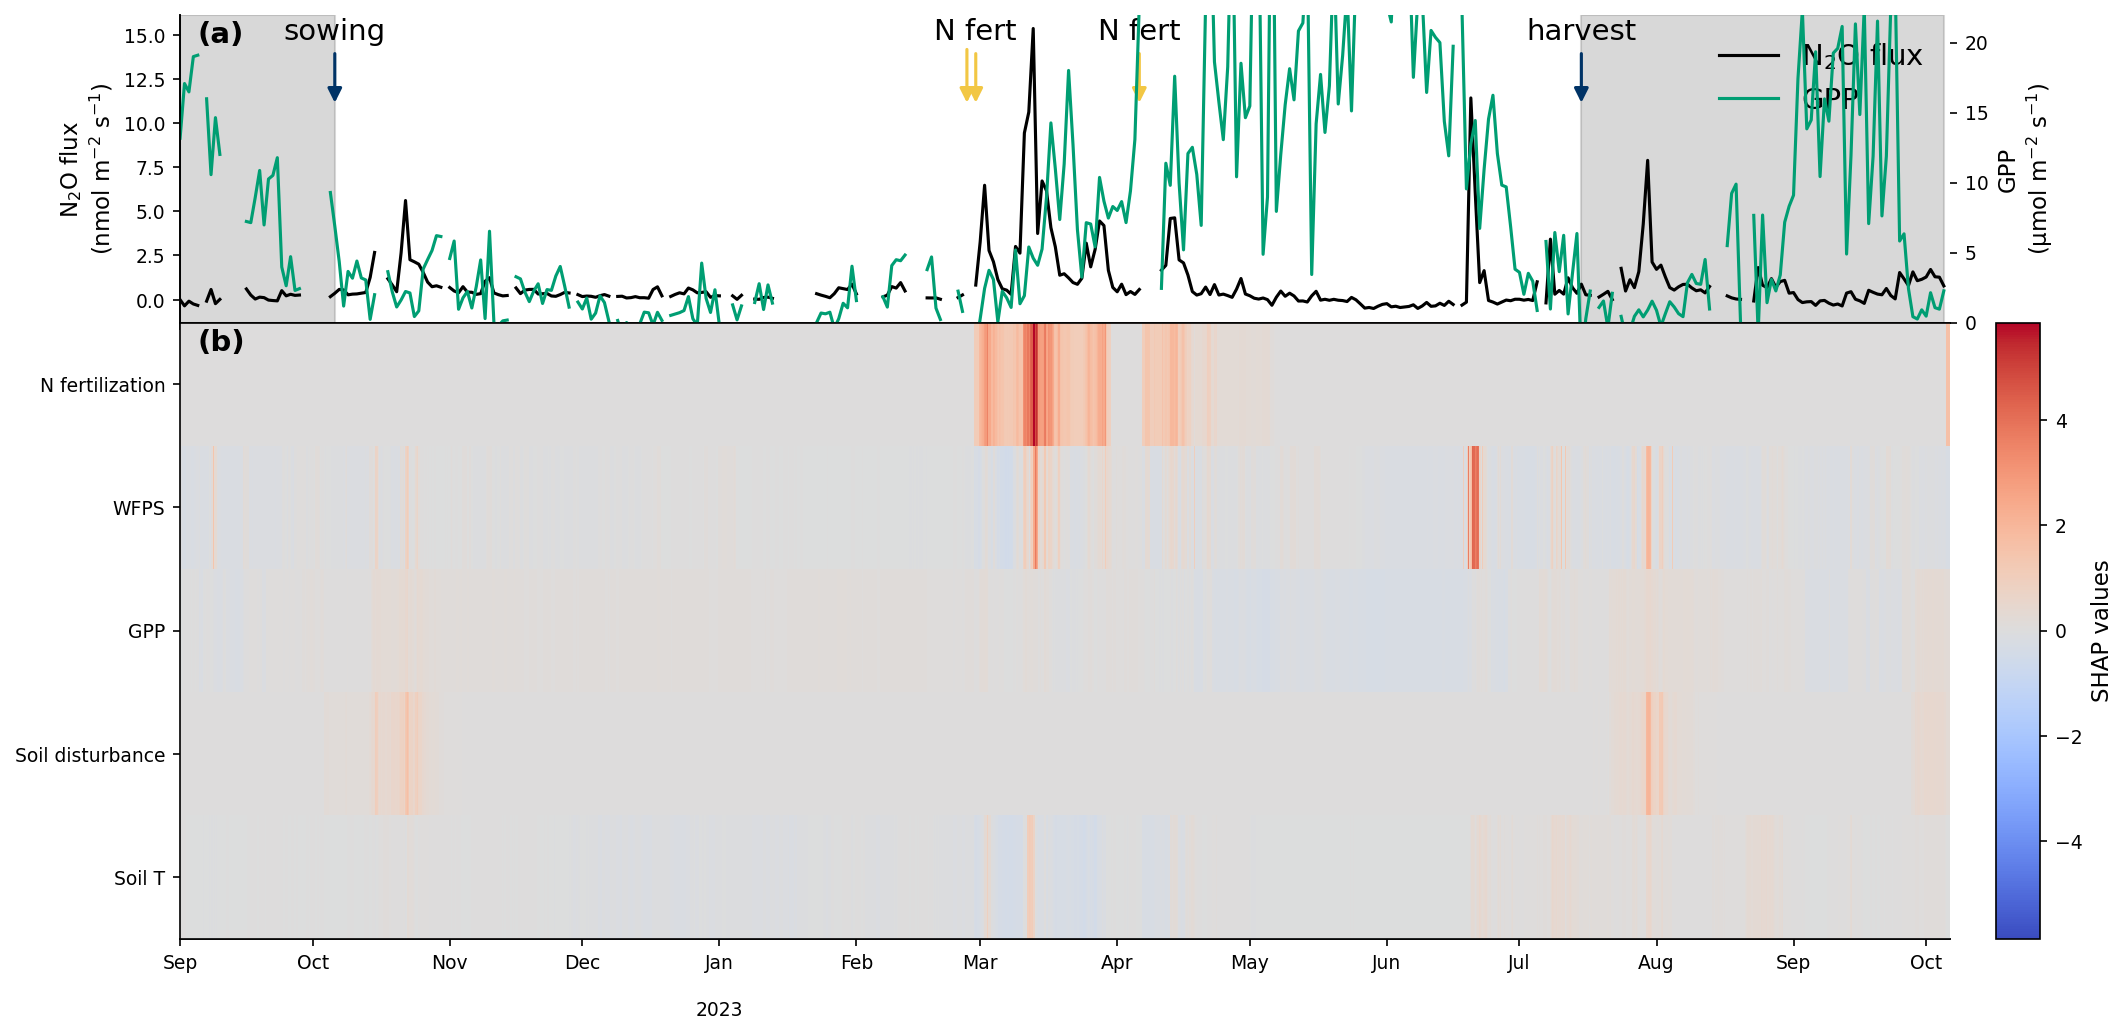

In [59]:
# Create figure with 2 rows, 2 columns (second column for SHAP colorbar)
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(nrows=2, ncols=2, width_ratios=[20, 0.5], height_ratios=[1, 2], hspace=0, wspace=0.05)

# Create subplots
ax_flux = fig.add_subplot(gs[0, 0])
ax_shap = fig.add_subplot(gs[1, 0], sharex=ax_flux)
cax = fig.add_subplot(gs[1, 1])  # colorbar axis for SHAP

# Add letters to subplots
ax_flux.text(0.01, 0.98, '(a)', transform=ax_flux.transAxes, fontweight='bold', verticalalignment='top')
ax_shap.text(0.01, 0.99, '(b)', transform=ax_shap.transAxes, fontweight='bold', verticalalignment='top')

# Call your functions
plot_flux_timeseries(fn2o_agg, gpp_agg, ax=ax_flux, linewidth=1.5)
plot_shap_heatmap(shap_df, ax=ax_shap, cax=cax, label='SHAP values')
plt.show()

## OVERALL CONTRIBUTIONS
Total contribution of each driver across the period, separate for positive and negative contributions

In [60]:
positive_contribution = (shap_df[shap_df > 0].sum() / shap_df[shap_df > 0].sum().sum()) * 100
negative_contribution = (shap_df[shap_df < 0].abs().sum() / shap_df[shap_df < 0].abs().sum().sum()) * 100
print('% positive contribution')
print(positive_contribution)
print()
print('% negative contribution')
print(negative_contribution)

% positive contribution
N fertilization     43.219894
WFPS                18.558075
GPP                 16.829480
Soil disturbance    12.437859
Soil T               8.954692
dtype: float64

% negative contribution
N fertilization      0.000000
WFPS                41.238112
GPP                 30.289389
Soil disturbance     0.003378
Soil T              28.469121
dtype: float64


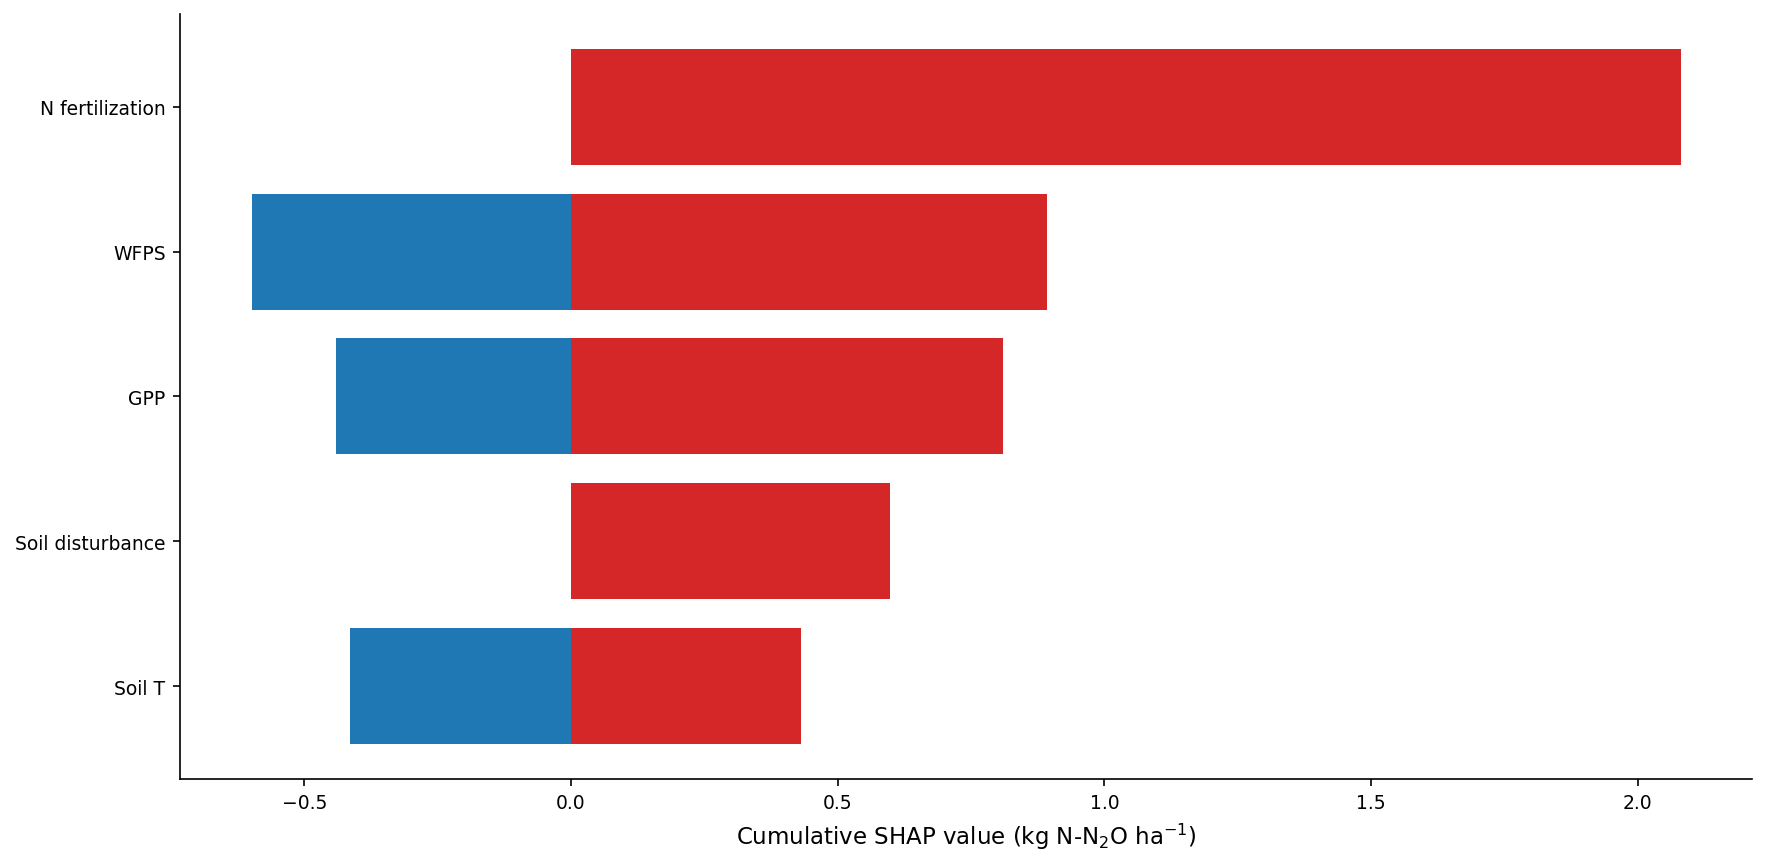

In [61]:
# Get cumulative sums

pos_sum = shap_df[shap_df > 0].sum()
neg_sum = shap_df[shap_df < 0].sum()

# Convert units
pos_sum = pos_sum * 60 * 60 * float(TIME_RESOLUTION) * 28.014 * 1e-9 * 1e-3 * 1e4 # nmol N2O m-2 s-1 → kg N2O-N ha-1 per averaging period (e.g., 4 hours)
neg_sum = neg_sum * 60 * 60 * float(TIME_RESOLUTION) * 28.014 * 1e-9 * 1e-3 * 1e4 # nmol N2O m-2 s-1 → kg N2O-N ha-1 per averaging period (e.g., 4 hours)

# Combine for plotting
contrib_df = pd.concat([pos_sum.rename('Positive'), neg_sum.rename('Negative')], axis=1).fillna(0)

# Plot mirrored bars
plt.rcParams.update({'font.size': 14})  # Set global font size
fig, ax = plt.subplots(figsize=(12, 6))
features = contrib_df.index
ax.barh(features, contrib_df['Negative'], color='#1f77b4')
ax.barh(features, contrib_df['Positive'], color='#d62728')
ax.invert_yaxis() # Reverse y-axis to have the highest positive contributions on top
ax.set_xlabel("Cumulative SHAP value (kg N-N$_{2}$O ha$^{-1}$)")
plt.tight_layout()
# save fig
plt.savefig('../figures/shap_contributions_summary.png', dpi=300, bbox_inches="tight")
plt.show()

## SHAP SCATTERPLOTS

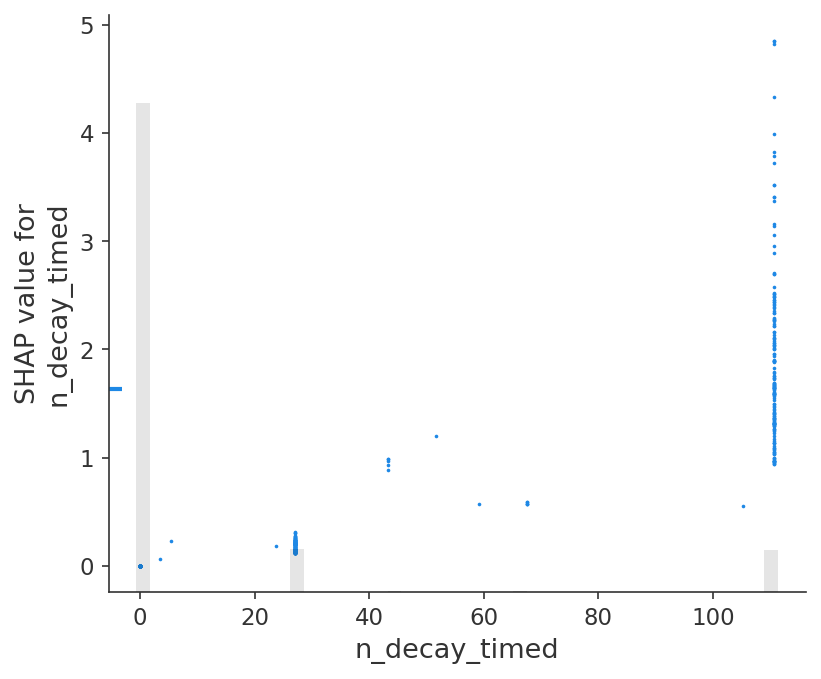

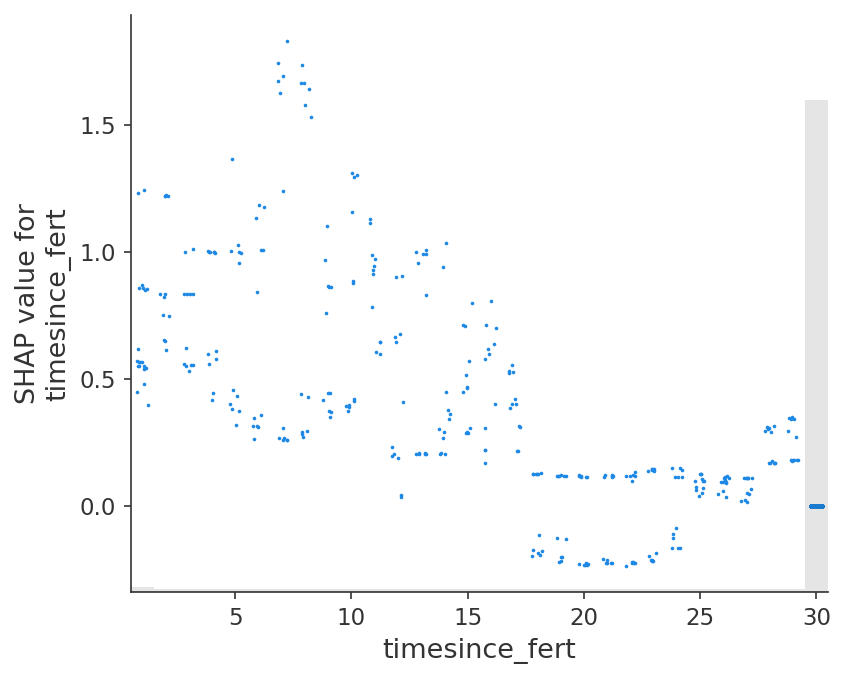

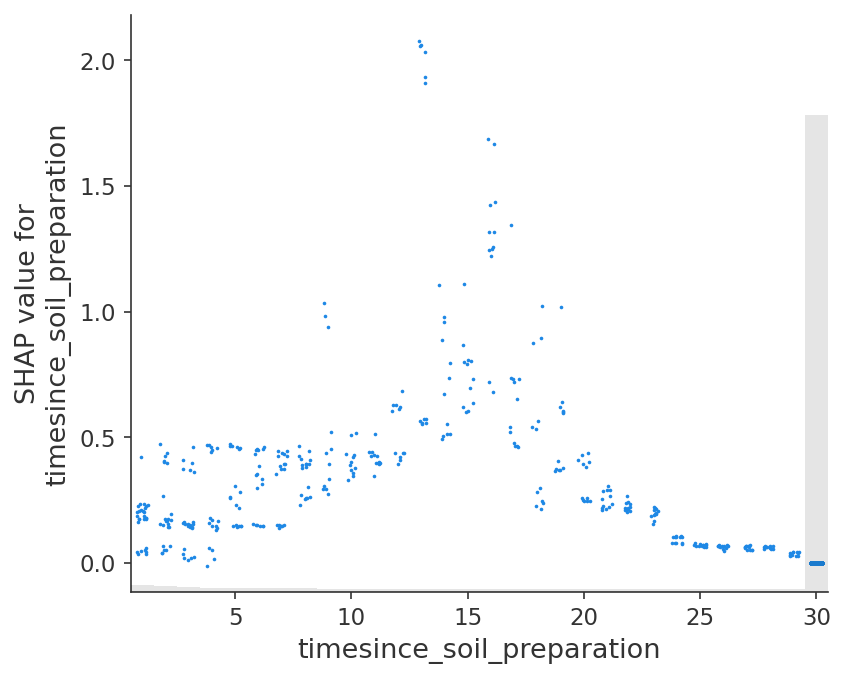

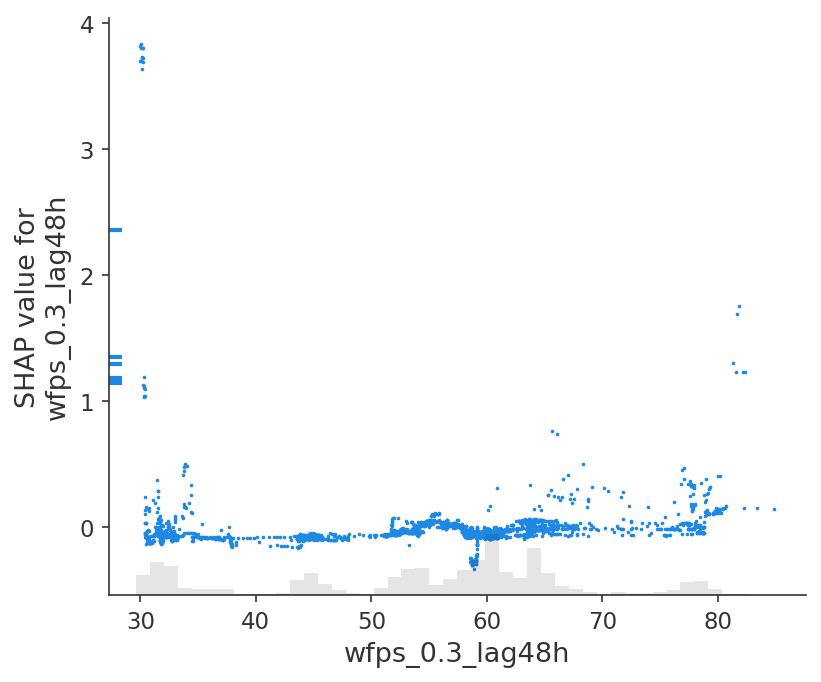

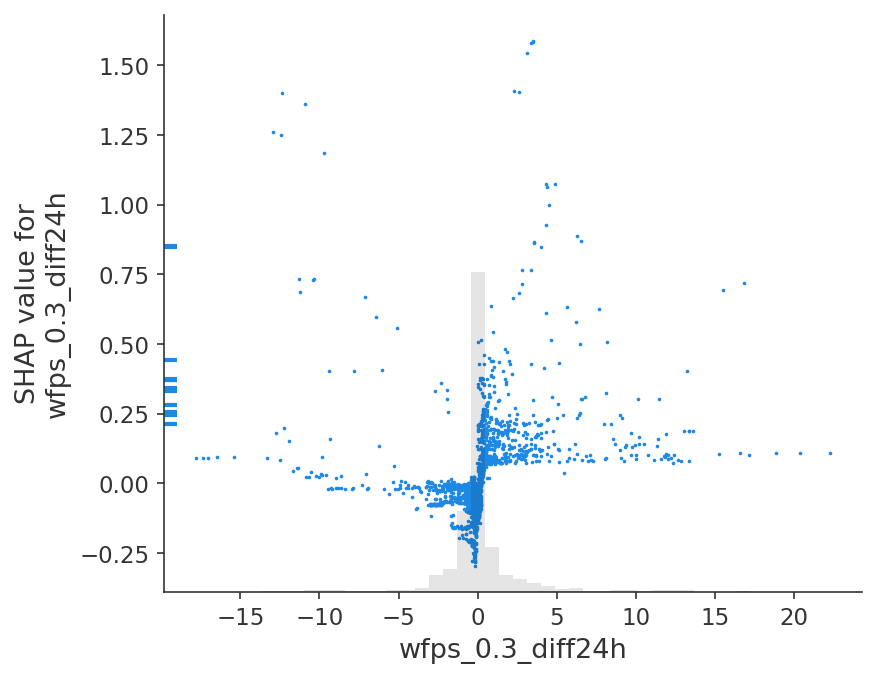

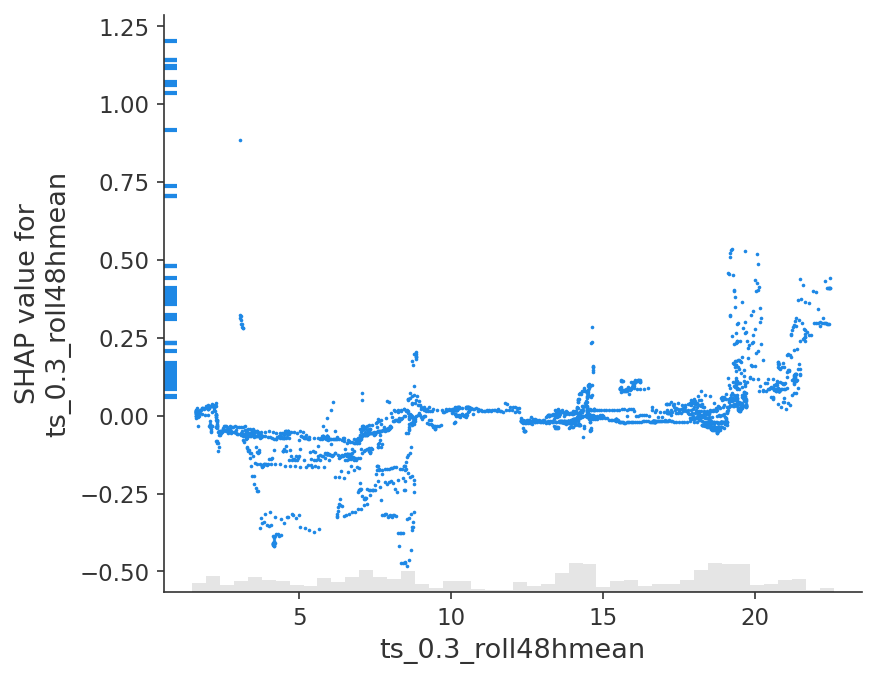

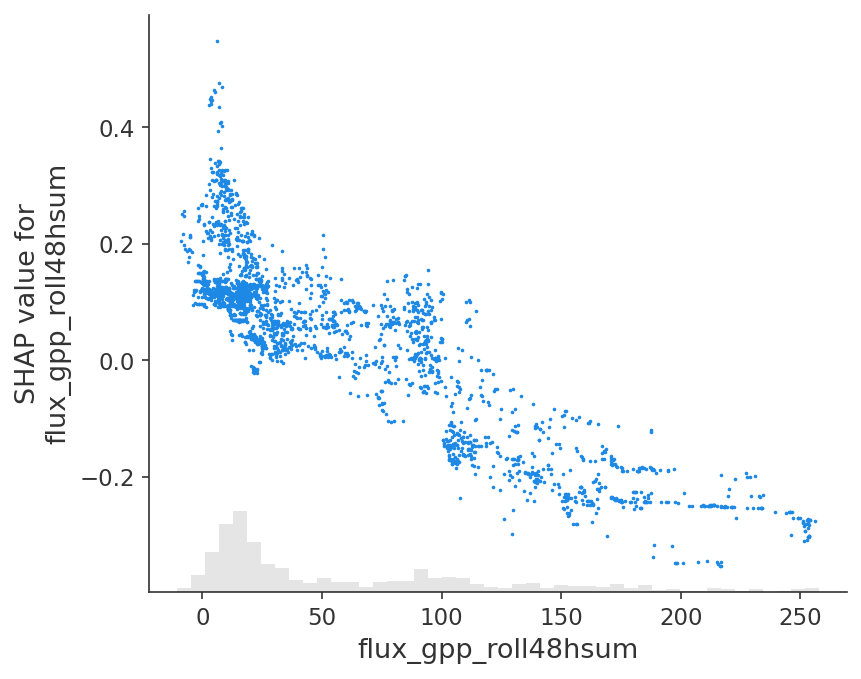

In [62]:
# Dependence plots
for var in X.columns:
    shap.plots.scatter(shap_values[:, var], dot_size=3, x_jitter=0.5)
#    shap.dependence_plot(var, shap_values.values, X)
    plt.show()

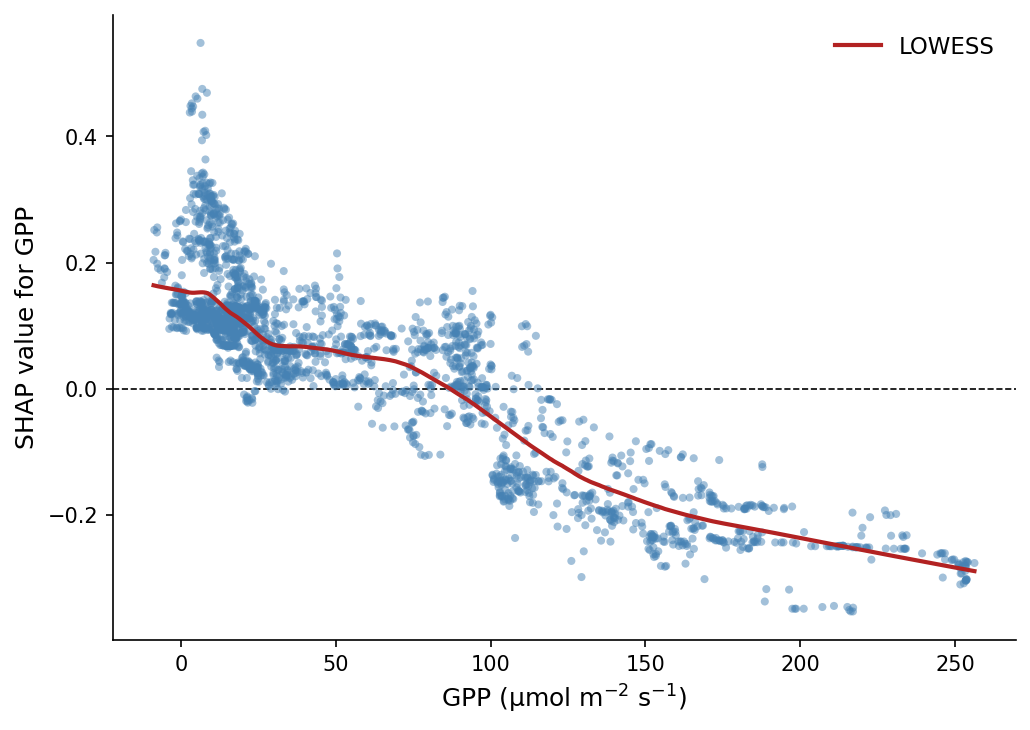

In [63]:
# ── Extract GPP feature and its SHAP values ───────────────────────────────────
gpp_vals  = X['flux_gpp_roll48hsum'].values
shap_gpp  = shap_values.values[:, X.columns.get_loc('flux_gpp_roll48hsum')]

# ── LOWESS smoother ───────────────────────────────────────────────────────────
smooth = lowess(shap_gpp, gpp_vals, frac=0.3, return_sorted=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
})

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    gpp_vals, shap_gpp,
    color="steelblue", edgecolors="none",
    alpha=0.5, s=15, zorder=2,
)
ax.plot(
    smooth[:, 0], smooth[:, 1],
    color="firebrick", lw=2, zorder=3, label="LOWESS",
)
ax.axhline(0, color="k", lw=0.8, linestyle="dashed", zorder=1)

ax.set_xlabel(r"GPP (µmol m$^{-2}$ s$^{-1}$)")
ax.set_ylabel("SHAP value for GPP")
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig('../figures/SHAP_GPP_dependence.png', dpi=300, bbox_inches="tight")
plt.show()

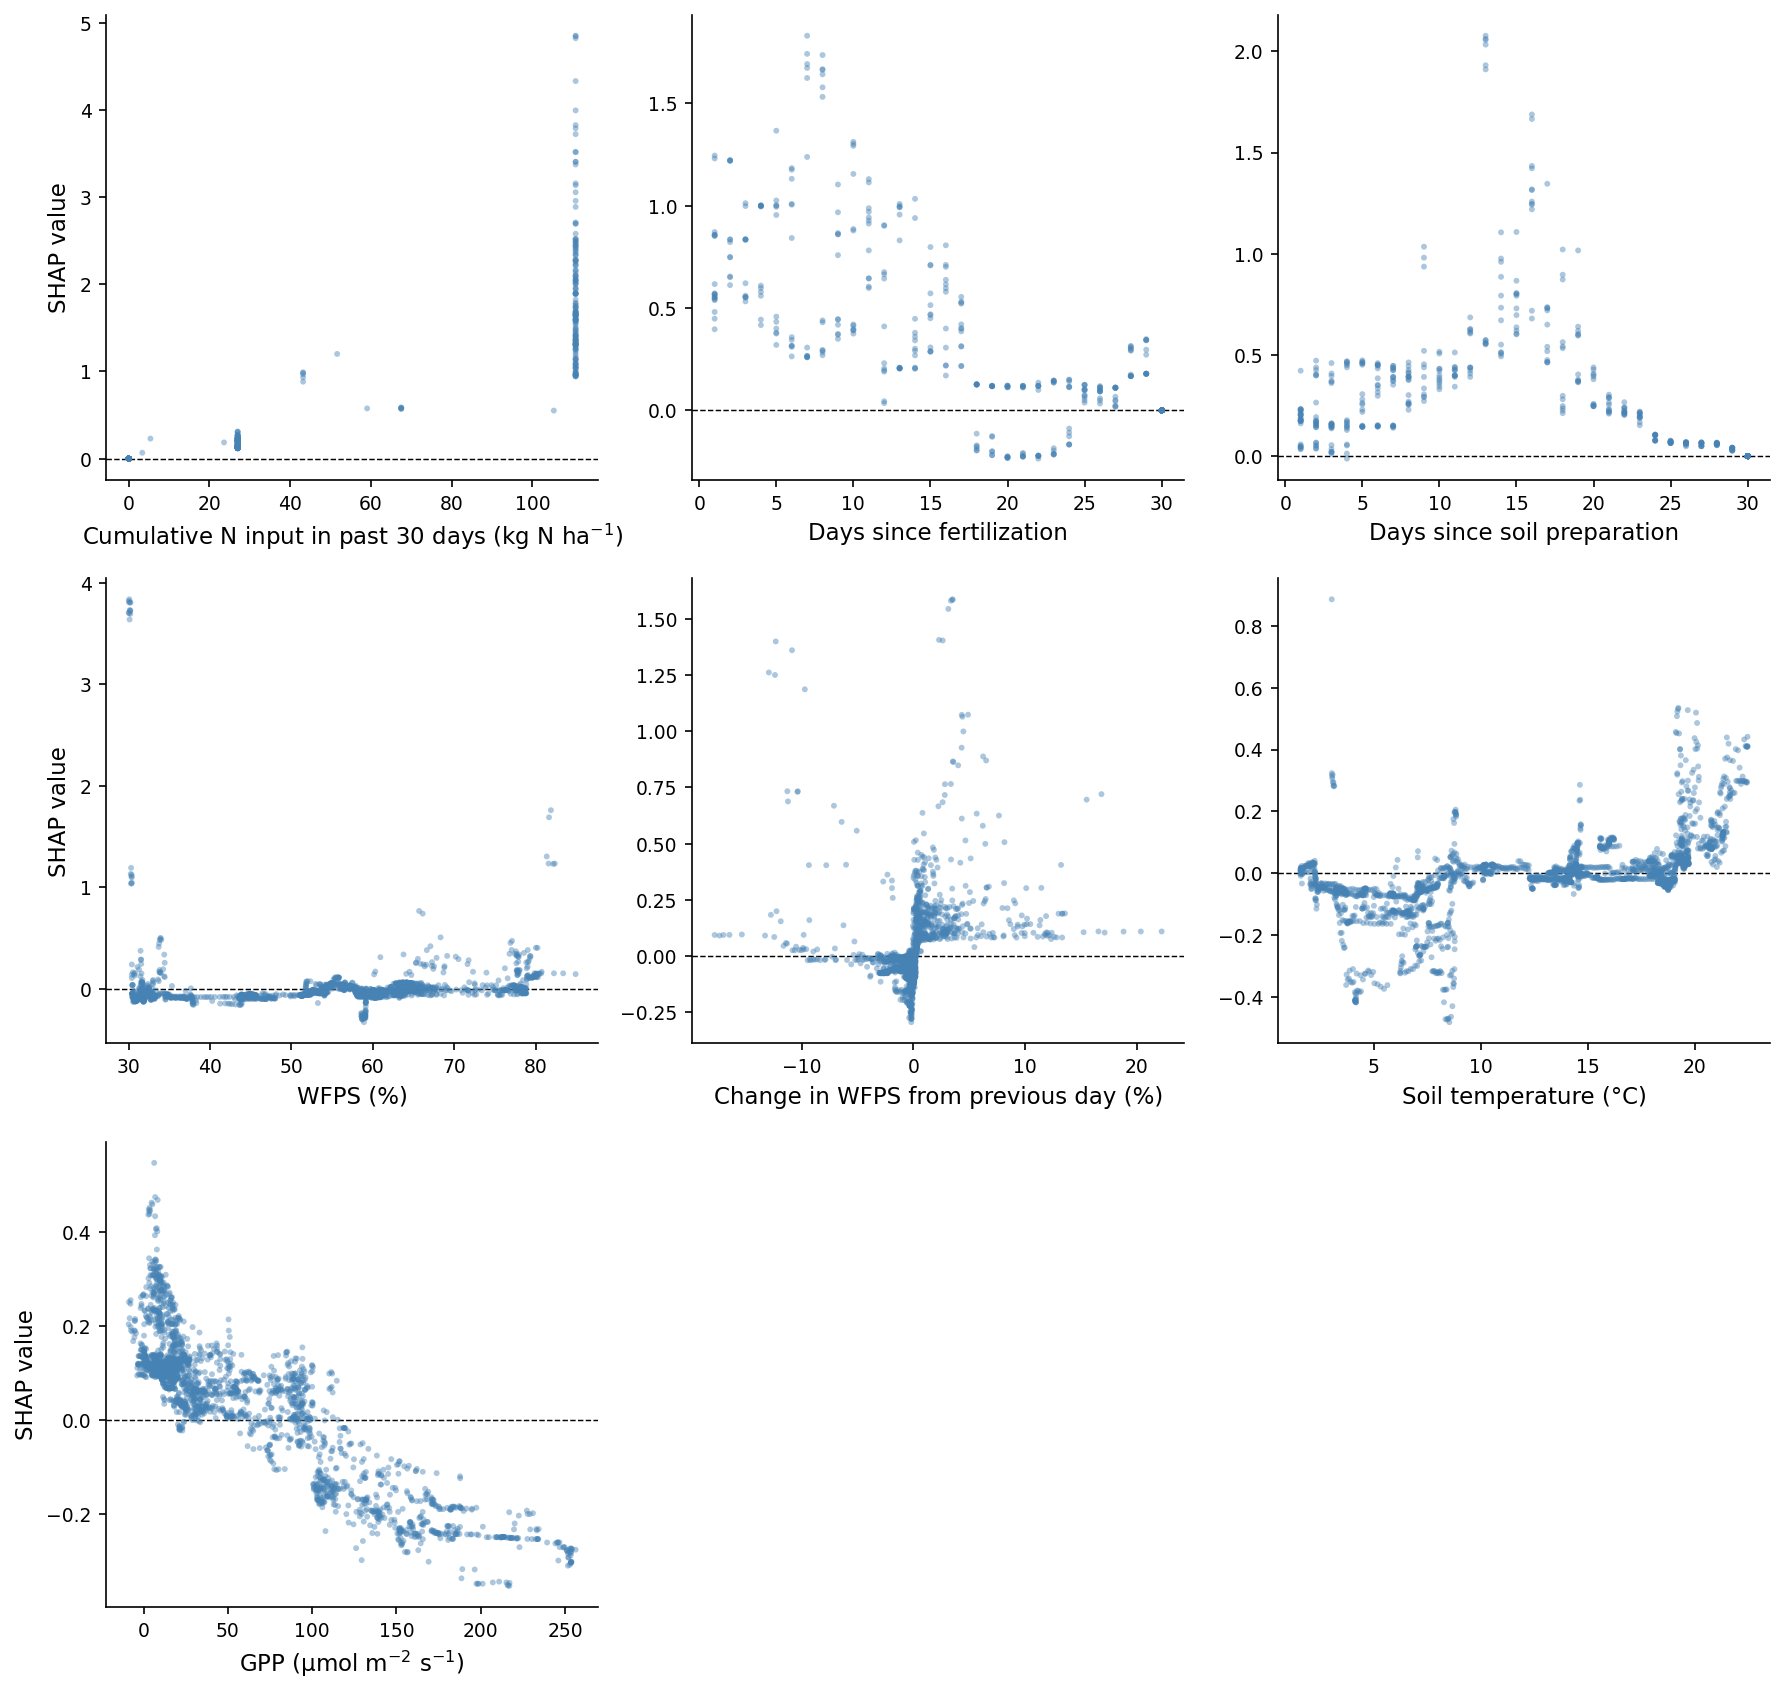

In [64]:
import numpy as np
import matplotlib.pyplot as plt

label_map = {
    'flux_gpp_roll48hsum':        r"GPP (µmol m$^{-2}$ s$^{-1}$)",
    'wfps_0.3_lag48h':            "WFPS (%)",
    'wfps_0.3_diff24h':           "Change in WFPS from previous day (%)",
    'timesince_soil_preparation': "Days since soil preparation",
    'timesince_fert':             "Days since fertilization",
    'ts_0.3_roll48hmean':         "Soil temperature (°C)",
    'n_decay_timed':              r"Cumulative N input in past 30 days (kg N ha$^{-1}$)",
}

def get_label(col):
    return label_map.get(col, col)

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         10,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
})

cols   = list(X.columns)
n_vars = len(cols)
ncols  = 3
nrows  = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.8))
axes_flat = axes.flatten()

for i, var in enumerate(cols):
    ax = axes_flat[i]

    feat_vals = X[var].values
    shap_vals = shap_values.values[:, X.columns.get_loc(var)]

    ax.scatter(
        feat_vals, shap_vals,
        color="steelblue", edgecolors="none",
        alpha=0.45, s=8, zorder=2,
    )
    ax.axhline(0, color="k", lw=0.7, linestyle="dashed", zorder=1)

    ax.set_xlabel(get_label(var))
    ax.set_ylabel("SHAP value" if i % ncols == 0 else "")

for j in range(n_vars, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/SHAP_dependence_all.png', dpi=300, bbox_inches="tight")
plt.show()